# 1 . Carga dos Dados

### 1.1 Objetivo
Para facilitar a reprodução do notebook, os arquivos do SINASC foram mantidos em um repositório no GitHub na mesma estrutura de diretórios e arquivos Parquet disponibilizada na avaliação. No início do notebook, o repositório é carregado no ambiente do Colab e os arquivos são lidos diretamente pelo PySpark.
Já a base de municípios e estados do IBGE é carregada a partir da URL indicada no enunciado.

Dessa forma, não é necessário configurar caminhos locais ou fazer upload manual dos arquivos para executar o notebook.

Com isso, o processo de carregamento fica concentrado no próprio notebook e pode ser reproduzido em outro ambiente com acesso ao repositório e às fontes utilizadas.

In [1]:
!git clone https://github.com/marlonmoreira1/teste-cidacs.git /content/teste-cidacs

Cloning into '/content/teste-cidacs'...
remote: Enumerating objects: 2064, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 2064 (delta 1), reused 0 (delta 0), pack-reused 2056 (from 1)
Receiving objects: 100% (2064/2064), 55.94 MiB | 14.59 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (2132/2132), done.


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Teste CIDACS")
    .getOrCreate()
)

In [3]:
SINASC_DIR = "/content/teste-cidacs/sinasc_2020_2022"

In [4]:
from pyspark.sql.functions import input_file_name

df_sinasc = (
    spark.read
    .option("recursiveFileLookup", "true")
    .parquet(SINASC_DIR)
)

df_sinasc = df_sinasc.withColumn(
    "_arquivo_origem",
    input_file_name()
)

df_sinasc.printSchema()

root
 |-- CODMUNNASC: string (nullable = true)
 |-- LOCNASC: string (nullable = true)
 |-- CODMUNRES: string (nullable = true)
 |-- DTNASC: string (nullable = true)
 |-- SEXO: string (nullable = true)
 |-- RACACOR: string (nullable = true)
 |-- PESO: string (nullable = true)
 |-- IDADEMAE: string (nullable = true)
 |-- ESTCIVMAE: string (nullable = true)
 |-- ESCMAE: string (nullable = true)
 |-- GRAVIDEZ: string (nullable = true)
 |-- CONSULTAS: string (nullable = true)
 |-- RACACORMAE: string (nullable = true)
 |-- DTNASCMAE: string (nullable = true)
 |-- GESTACAO: string (nullable = true)
 |-- SEMAGESTAC: string (nullable = true)
 |-- CONSPRENAT: string (nullable = true)
 |-- PARTO: string (nullable = true)
 |-- CODESTAB: string (nullable = true)
 |-- _arquivo_origem: string (nullable = false)



In [5]:
print(f"Quantidade de registros: {df_sinasc.count():,}")
print(f"Quantidade de colunas: {len(df_sinasc.columns)}")

Quantidade de registros: 3,999,785
Quantidade de colunas: 20


### 1.2 Coluna Ausente
Durante a conferência das variáveis, foi identificado que `TPNASCASSI` está presente no dicionário de dados, mas não está disponível na base fornecida. Ela não é necessária para responder as perguntas da análise.


In [6]:
df_sinasc.show(5, truncate=False)

+----------+-------+---------+--------+----+-------+------+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------------------------------------------------------------------------------------------------------------------------------+
|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC  |SEXO|RACACOR|PESO  |IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem                                                                                                                        |
+----------+-------+---------+--------+----+-------+------+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------------------------------------------------------------------------------------------------------------------------------+
|355030    |1      |355030   |03052020|2   |1      |2700+ |37      |1       

In [7]:
import requests

IBGE_URL = (
    "https://raw.githubusercontent.com/"
    "leogermani/estados-e-municipios-ibge/master/municipios.csv"
)

IBGE_PATH = "/content/municipios.csv"

response = requests.get(IBGE_URL)
response.raise_for_status()

with open(IBGE_PATH, "wb") as f:
    f.write(response.content)

In [8]:
ibge_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(IBGE_PATH)
)

In [9]:
ibge_df.printSchema()

root
 |-- COD UF: integer (nullable = true)
 |-- COD: integer (nullable = true)
 |-- NOME: string (nullable = true)



In [10]:
print(f"Quantidade de registros: {ibge_df.count():,}")
print(f"Quantidade de colunas: {len(ibge_df.columns)}")

Quantidade de registros: 5,570
Quantidade de colunas: 3


In [11]:
ibge_df.show(5, truncate=False)

+------+-------+---------------------+
|COD UF|COD    |NOME                 |
+------+-------+---------------------+
|11    |1100015|Alta Floresta D'oeste|
|11    |1100023|Ariquemes            |
|11    |1100031|Cabixi               |
|11    |1100049|Cacoal               |
|11    |1100056|Cerejeiras           |
+------+-------+---------------------+
only showing top 5 rows


### 1.3 Escolha da ferramenta de processamento

O PySpark foi escolhido como ferramenta principal devido ao volume da base do SINASC, com aproximadamente 4 milhões de registros, mantendo no mesmo ambiente as etapas de exploração, transformação, joins e agregações. A base do IBGE também será mantida em Spark para evitar conversões desnecessárias entre ferramentas.

Na etapa da análise dos dados (as 17 questões), resultados já agregados e filtrados serão convertidos para pandas para análise e visualização dos dados.


# 2 . Exploração e Análise Descritiva dos Dados

### 2.1 Objetivo
A ideia aqui é fazer uma análise inicial das bases para verificar sua estrutura, completude e possíveis inconsistências nos dados. O objetivo é avaliar aspectos como quantidade de registros, valores nulos, duplicidades, valores distintos e formatos dos campos.

Caso haja inconsistências que possam afetar as análises, elas serão tratadas antes da estruturação da base, com a abordagem adotada devidamente justificada.


### 2.2 Base do IBGE

In [12]:
from pyspark.sql.functions import col, count, when, length, substring, trim
# verificando a existência de valores nulos
ibge_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in ibge_df.columns
]).show()

+------+---+----+
|COD UF|COD|NOME|
+------+---+----+
|     0|  0|   0|
+------+---+----+



In [13]:
ibge_df.select([
    count(
        when(
            (trim(col(c)) == ""),
            c
        )
    ).alias(c)
    for c in ibge_df.columns
]).show()

+------+---+----+
|COD UF|COD|NOME|
+------+---+----+
|     0|  0|   0|
+------+---+----+



In [14]:
for c in ibge_df.columns:
    print(
        f"{c}: {ibge_df.select(c).distinct().count():,} valores distintos"
    )

COD UF: 27 valores distintos
COD: 5,570 valores distintos
NOME: 5,297 valores distintos


In [15]:
duplicados = ibge_df.count() - ibge_df.dropDuplicates().count()

print(f"Registros duplicados: {duplicados:,}")

Registros duplicados: 0


#### Municípios com mesmo nome em UFs diferentes?
A base do IBGE possui 5.570 códigos de municípios e 5.297 nomes distintos. Uma hipótese é que essa diferença ocorre porque existem municípios com o mesmo nome em UFs diferentes.

In [16]:
ibge_df.groupBy("NOME").count().filter(
    col("count") > 1
).orderBy(
    col("count").desc()
).show(20, truncate=False)

+---------------+-----+
|NOME           |count|
+---------------+-----+
|São domingos   |5    |
|Bom Jesus      |5    |
|Santa Inês     |4    |
|São Francisco  |4    |
|Santa Helena   |4    |
|Bonito         |4    |
|Planalto       |4    |
|Vera Cruz      |4    |
|Santa Luzia    |4    |
|Santa Cruz     |3    |
|Triunfo        |3    |
|Mundo Novo     |3    |
|Itambé         |3    |
|Cruzeiro do Sul|3    |
|Novo Horizonte |3    |
|Jussara        |3    |
|Nova Olinda    |3    |
|Ouro Branco    |3    |
|Alto Alegre    |3    |
|Belém          |3    |
+---------------+-----+
only showing top 20 rows


In [17]:
ibge_df.filter(
    col("NOME") == "Belém"
).show(truncate=False)

+------+-------+-----+
|COD UF|COD    |NOME |
+------+-------+-----+
|15    |1501402|Belém|
|25    |2501906|Belém|
|27    |2700805|Belém|
+------+-------+-----+



#### Hipótese Confirmada
A diferença acontece porque existem municípios com o mesmo nome em UFs diferentes mesmo.

In [18]:
# verificar se o código tem sempre 7 dígitos como esperado
ibge_df.filter(
    length(col("COD").cast("string")) != 7
).count()

0

In [19]:
# Assim como no código de município do SINASC os 2 primeiros dígitos são o código da UF?
ibge_df.filter(
    substring(col("COD").cast("string"), 1, 2) != col("COD UF").cast("string")
).count()

0

In [20]:
# algo inesperado fora dos dígitos númericos
ibge_df.filter(
    ~col("COD").cast("string").rlike(r"^[0-9]{7}$")
).count()

0

In [21]:
ibge_df.filter(
    col("NOME").isNull() | (col("NOME") == "")
).count()

0

In [22]:
ibge_df.filter(
    col("NOME") != trim(col("NOME"))
).show(truncate=False)

+------+---+----+
|COD UF|COD|NOME|
+------+---+----+
+------+---+----+



#### Conclusão da base do IBGE
A base do IBGE não apresentou inconsistências nos checks realizados. Os códigos e nomes estão no formato esperado e o código do município pode ser usado como chave no relacionamento com o SINASC.


### 2.3 Base Sinasc

In [23]:
df_sinasc.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_sinasc.columns
]).show()

+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC|SEXO|RACACOR|PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem|
+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|         0|      0|        0|     0|   0|      0|   0|       0|        0|     0|       0|        0|         0|        0|       0|         0|         0|    0|       0|              0|
+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+



In [24]:
df_sinasc.select([
    count(when((trim(col(c)) == ""),c)).alias(c)
    for c in df_sinasc.columns
]).show()

+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC|SEXO|RACACOR|PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem|
+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|         0|      0|        0|     0|   0|  95253| 799|      52|    23195| 20926|    2870|     2815|    123898|    39845|   43659|     43773|     73275| 2410|   41667|              0|
+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+



#### Ausência de informação

A verificação mostrou **0 valores `null`**, mas identificou valores vazios em diversas variáveis. Isso demonstra que a ausência de informação está representada como texto vazio/espaços, e não como `null`, sendo necessário considerar esse padrão na etapa de limpeza.


In [25]:
df_sinasc.filter(
    trim(col("PARTO")) == ""
).select(
    "PARTO"
).show(20, truncate=False)

+-----+
|PARTO|
+-----+
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
|     |
+-----+
only showing top 20 rows


In [26]:
df_sinasc.filter(
    trim(col("RACACOR")) == ""
).select(
    "RACACOR",
    "RACACORMAE",
    "SEXO",
    "IDADEMAE",
    "PARTO"
).show(20, truncate=False)

+-------+----------+----+--------+-----+
|RACACOR|RACACORMAE|SEXO|IDADEMAE|PARTO|
+-------+----------+----+--------+-----+
|       |          |1   |32      |2    |
|       |          |2   |25      |2    |
|       |          |1   |42      |1    |
|       |          |2   |19      |1    |
|       |          |2   |28      |2    |
|       |          |1   |39      |2    |
|       |          |1   |23      |2    |
|       |          |2   |31      |2    |
|       |          |2   |37      |2    |
|       |          |2   |18      |2    |
|       |          |1   |27      |1    |
|       |          |1   |28      |1    |
|       |          |2   |21      |2    |
|       |          |2   |26      |2    |
|       |          |2   |35      |2    |
|       |          |1   |25      |2    |
|       |          |1   |32      |1    |
|       |          |2   |38      |2    |
|       |          |1   |21      |2    |
|       |          |1   |36      |2    |
+-------+----------+----+--------+-----+
only showing top

In [27]:
df_sinasc.select([
    count(
        when(
            (~trim(col(c)).rlike(r"^[0-9]+$")),
            c
        )
    ).alias(c)
    for c in df_sinasc.columns
]).show()

+----------+-------+---------+------+----+-------+-----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC|SEXO|RACACOR| PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem|
+----------+-------+---------+------+----+-------+-----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|    100744|  24760|        0| 45529|   0| 137521|84921|    3557|    23195| 20926|   21426|    33945|    137000|    50960|   81200|     91509|    109569|12950|   49851|        3999785|
+----------+-------+---------+------+----+-------+-----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+



In [28]:
colunas_para_verificar = [
    "CODMUNNASC",
    "LOCNASC",
    "DTNASC",
    "RACACOR",
    "PESO",
    "GRAVIDEZ",
    "CONSULTAS",
    "RACACORMAE",
    "DTNASCMAE",
    "GESTACAO",
    "SEMAGESTAC",
    "CONSPRENAT",
    "PARTO",
    "CODESTAB"
]

for c in colunas_para_verificar:
    print(f"\n--- {c} ---")

    (
        df_sinasc
        .filter(
            col(c).isNotNull() &
            (trim(col(c)) != "") &
            (~trim(col(c)).rlike(r"^[0-9]+$"))
        )
        .select(c)
        .distinct()
        .show(20, truncate=False)
    )


--- CODMUNNASC ---
+-------------+
|CODMUNNASC   |
+-------------+
|@ 355030     |
|350550 +#    |
|?!350280     |
|??350760 @   |
|#355030 ++   |
|#355030 *%   |
|?-355030 +#  |
|#!-355280 % @|
|%?350950     |
|354340 @+    |
|!%-354330 -@ |
|!+?354850    |
|!354520 *!!  |
|#354340 *!   |
|*+353300     |
|353060 -     |
|@-%353060    |
|352690 -!    |
|353870 %     |
| *%350660    |
+-------------+
only showing top 20 rows

--- LOCNASC ---
+-------+
|LOCNASC|
+-------+
|1?+-   |
|1*-@   |
|?*#1-? |
|-!+1%-!|
|#!-1   |
|+*1-!  |
|@*1%?  |
|%-%1   |
|@!1%   |
|@?1+@@ |
|@-%1-%+|
|%--1   |
|*1?!%  |
|#?1#*+ |
|??1 @  |
|#*1-*- |
|!1@-   |
|% %1+@ |
|@?+1%  |
|-+1%   |
+-------+
only showing top 20 rows

--- DTNASC ---
+-------------+
|DTNASC       |
+-------------+
| 03072022-   |
|*#16112022 ?%|
|10082022@    |
|14012022+@!  |
|07052022??   |
|18042022-#   |
|@23022022*%- |
|++-13042022  |
| 03032022%   |
|-!14052022?  |
|@-!11082022  |
|+19112022    |
|# ?28122022  |
|15122022@    |
|

In [29]:
duplicados = df_sinasc.count() - df_sinasc.dropDuplicates().count()
print("Duplicados:", duplicados)

Duplicados: 0


#### Conclusão da base SINASC

A exploração da base identificou problemas principalmente no preenchimento dos campos, com presença de caracteres, símbolos e espaços em variáveis que deveriam seguir padrões numéricos ou de código. Foram observadas ocorrências desse tipo em campos como `CODMUNNASC`, `DTNASC`, `RACACOR`, `PESO`, `CONSULTAS`, `GESTACAO`, `CONSPRENAT` e `PARTO`.

Também foi identificado que, embora a base original não apresente valores `null`, existem **células vazias ou preenchidas apenas com espaços**, principalmente em `RACACORMAE` (123.898), `RACACOR` (95.253), `CONSPRENAT` (73.275), `GESTACAO` (43.659) e `CODESTAB` (41.667).



# 3 . Limpeza

### 3.1 Objetivo
O objetivo aqui foi corrigir os valores sem perder informação que ainda pudesse ser aproveitada. Remover os espaços e caracteres que apareciam junto aos códigos e valores numéricos, mantendo apenas o conteúdo necessário para cada variável. Nos campos em que o dicionário define códigos específicos para informação ignorada, padronizei os valores de acordo com essa regra, e mantive como nulo aquilo que realmente não tinha informação.

In [30]:
from pyspark.sql.functions import col, trim, regexp_replace, when

# ============================================================
# CAMPOS QUE POSSUEM CÓDIGO ESPECÍFICO PARA "IGNORADO"
# ============================================================

# Para essas variáveis, o dicionário possui o código 9 = Ignorado.
categoricas_9 = [
    "LOCNASC",
    "ESTCIVMAE",
    "ESCMAE",
    "GRAVIDEZ",
    "CONSULTAS",
    "PARTO",
    "GESTACAO"
]

# Sexo possui 0 = Ignorado.
categoricas_0 = [
    "SEXO"
]

# ============================================================
# CAMPOS QUE DEVEM CONTER APENAS DÍGITOS
# ============================================================

campos_numericos = [
    "LOCNASC",
    "RACACOR",
    "PESO",
    "IDADEMAE",
    "ESTCIVMAE",
    "ESCMAE",
    "GRAVIDEZ",
    "CONSULTAS",
    "RACACORMAE",
    "GESTACAO",
    "SEMAGESTAC",
    "CONSPRENAT",
    "PARTO",
    "CODESTAB"
]

# ============================================================
# LIMPEZA DOS CAMPOS NUMÉRICOS E CATEGÓRICOS CODIFICADOS
# ============================================================

df_sinasc = df_sinasc.select([
    (
        when(
            regexp_replace(trim(col(c)), r"[^0-9]", "") == "",
            None
        ).otherwise(
            regexp_replace(trim(col(c)), r"[^0-9]", "")
        ).alias(c)
        if c in campos_numericos
        else trim(col(c)).alias(c)
    )
    for c in df_sinasc.columns
])

# ============================================================
# MUNICÍPIOS
# ============================================================

# CODMUNNASC e CODMUNRES possuem 6 dígitos ou "EX".
for c in ["CODMUNNASC", "CODMUNRES"]:
    df_sinasc = df_sinasc.withColumn(
        c,
        when(
            trim(col(c)) == "",
            None
        ).when(
            trim(col(c)) == "EX",
            "EX"
        ).otherwise(
            when(
                regexp_replace(trim(col(c)), r"[^0-9]", "") == "",
                None
            ).otherwise(
                regexp_replace(trim(col(c)), r"[^0-9]", "")
            )
        )
    )

# ============================================================
# DATAS
# ============================================================

# Mantém somente os dígitos das datas.
# Se não houver nenhum dígito, transforma em NULL.
for c in ["DTNASC", "DTNASCMAE"]:
    df_sinasc = df_sinasc.withColumn(
        c,
        when(
            regexp_replace(trim(col(c)), r"[^0-9]", "") == "",
            None
        ).otherwise(
            regexp_replace(trim(col(c)), r"[^0-9]", "")
        )
    )

# ============================================================
# PADRONIZAÇÃO DOS VALORES AUSENTES
# ============================================================

# Variáveis cujo dicionário possui 9 = Ignorado.
for c in categoricas_9:
    df_sinasc = df_sinasc.withColumn(
        c,
        when(
            col(c).isNull() | (trim(col(c)) == ""),
            "9"
        ).otherwise(col(c))
    )

# Sexo possui 0 = Ignorado.
df_sinasc = df_sinasc.withColumn(
    "SEXO",
    when(
        col("SEXO").isNull() | (trim(col("SEXO")) == ""),
        "0"
    ).otherwise(col("SEXO"))
)

In [31]:
df_sinasc.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_sinasc.columns
]).show()

+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC|SEXO|RACACOR|PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem|
+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+
|         0|      0|        0|     0|   0|  96421| 800|      52|        0|     0|       0|        0|    124154|    39862|       0|     45475|     73853|    0|   41703|              0|
+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+



In [32]:
df_sinasc = df_sinasc.dropDuplicates()

# 4 . Estruturação da base

### 4.1 Objetivo
Depois da limpeza, organizei a base da SINASC para criar as variáveis que seriam usadas nas análises. Para relacionar a base com os dados do IBGE, verifiquei a diferença entre os códigos de município: na SINASC o código possui 6 dígitos, enquanto o código completo do IBGE possui 7, sendo o último o dígito verificador (usado para validar o código). Assim, os 6 primeiros dígitos do código do IBGE correspondem ao código utilizado na SINASC e podem ser usados na junção. A partir desse relacionamento, obtive o código da UF, município, sigla e nome da UF de nascimento. Também extraí o ano e a UF de coleta pela origem dos arquivos, **calculei a `IDADE_MAE_CRIADA` a partir da diferença entre `DTNASC` (data de nascimento da criança) e `DTNASCMAE` (data de nascimento da mãe), obtendo a idade em anos completos**, e criei a variável `COMPRIMENTO_PESO`.



In [33]:
from pyspark.sql.functions import (
    input_file_name,
    regexp_extract,
    col,
    substring,
    lpad,
    length,
    to_date,
    floor,
    months_between
)

df_sinasc = (
    df_sinasc
    .withColumn(
        "UF_COLETA",
        regexp_extract(col("_arquivo_origem"), r"/DN([A-Z]{2})20\d{2}/", 1)
    )
    .withColumn(
        "ANO_COLETA",
        regexp_extract(col("_arquivo_origem"), r"/DN[A-Z]{2}(20\d{2})/", 1)
    )
)

df_sinasc.select(
    "UF_COLETA",
    "ANO_COLETA",
    "_arquivo_origem"
).distinct().orderBy(
    "ANO_COLETA",
    "UF_COLETA"
).show(25, truncate=False)

+---------+----------+---------------------------------------------------------------------------------------------------------------------------------------+
|UF_COLETA|ANO_COLETA|_arquivo_origem                                                                                                                        |
+---------+----------+---------------------------------------------------------------------------------------------------------------------------------------+
|AC       |2020      |file:///content/teste-cidacs/sinasc_2020_2022/sinasc_2020_2022/DNAC2020/part-00004-af75a2b5-1c69-446c-9834-87e7901b7188-c000.gz.parquet|
|AC       |2020      |file:///content/teste-cidacs/sinasc_2020_2022/sinasc_2020_2022/DNAC2020/part-00011-af75a2b5-1c69-446c-9834-87e7901b7188-c000.gz.parquet|
|AC       |2020      |file:///content/teste-cidacs/sinasc_2020_2022/sinasc_2020_2022/DNAC2020/part-00001-af75a2b5-1c69-446c-9834-87e7901b7188-c000.gz.parquet|
|AC       |2020      |file:///content/teste-ci

In [34]:
ibge_df.filter(
    col("COD").cast("string").startswith("355030")
).show(truncate=False)

+------+-------+---------+
|COD UF|COD    |NOME     |
+------+-------+---------+
|35    |3550308|São Paulo|
+------+-------+---------+



In [80]:
ibge_df.filter(
    col("NOME") == 'Curitiba'
).show(truncate=False)

+------+-------+--------+
|COD UF|COD    |NOME    |
+------+-------+--------+
|41    |4106902|Curitiba|
+------+-------+--------+



In [35]:
ibge_join = (
    ibge_df
    .withColumn(
        "CODMUNNASC_JOIN",
        substring(col("COD").cast("string"), 1, 6)
    )
)

In [36]:
df_sinasc = df_sinasc.withColumn(
    "COD_UF_NASC",
    substring(col("CODMUNNASC"), 1, 2)
)

In [37]:
df_sinasc = (
    df_sinasc
    .join(
        ibge_join.select(
            "CODMUNNASC_JOIN",
            col("NOME").alias("NOME_MUNIC_NASC")
        ),
        df_sinasc["CODMUNNASC"] == ibge_join["CODMUNNASC_JOIN"],
        "left"
    )
    .drop("CODMUNNASC_JOIN")
)

In [38]:
from pyspark.sql.types import StructType, StructField, StringType

ufs = [
    ("11", "RO", "Rondônia"),
    ("12", "AC", "Acre"),
    ("13", "AM", "Amazonas"),
    ("14", "RR", "Roraima"),
    ("15", "PA", "Pará"),
    ("16", "AP", "Amapá"),
    ("17", "TO", "Tocantins"),
    ("21", "MA", "Maranhão"),
    ("22", "PI", "Piauí"),
    ("23", "CE", "Ceará"),
    ("24", "RN", "Rio Grande do Norte"),
    ("25", "PB", "Paraíba"),
    ("26", "PE", "Pernambuco"),
    ("27", "AL", "Alagoas"),
    ("28", "SE", "Sergipe"),
    ("29", "BA", "Bahia"),
    ("31", "MG", "Minas Gerais"),
    ("32", "ES", "Espírito Santo"),
    ("33", "RJ", "Rio de Janeiro"),
    ("35", "SP", "São Paulo"),
    ("41", "PR", "Paraná"),
    ("42", "SC", "Santa Catarina"),
    ("43", "RS", "Rio Grande do Sul"),
    ("50", "MS", "Mato Grosso do Sul"),
    ("51", "MT", "Mato Grosso"),
    ("52", "GO", "Goiás"),
    ("53", "DF", "Distrito Federal")
]

ufs_df = spark.createDataFrame(
    ufs,
    ["COD_UF_NASC", "SIGLA_UF_NASC", "NOME_UF_NASC"]
)

df_sinasc = df_sinasc.join(
    ufs_df,
    on="COD_UF_NASC",
    how="left"
)

In [39]:
df_sinasc = (
    df_sinasc
    .withColumn(
        "_DTNASC",
        to_date(when(col("DTNASC") != "", col("DTNASC")), "ddMMyyyy")
    )
    .withColumn(
        "_DTNASCMAE",
        to_date(when(col("DTNASCMAE") != "", col("DTNASCMAE")), "ddMMyyyy")
    )
    .withColumn(
        "IDADE_MAE_CRIADA",
        floor(
            months_between(
                col("_DTNASC"),
                col("_DTNASCMAE")
            ) / 12
        )
    )
    .drop("_DTNASC", "_DTNASCMAE")
)

In [40]:
df_sinasc.show(15, truncate=False)

+-----------+----------+-------+---------+--------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------------------------------------------------------------------------------------------------------------------------------+---------+----------+---------------+-------------+------------+----------------+
|COD_UF_NASC|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC  |SEXO|RACACOR|PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem                                                                                                                        |UF_COLETA|ANO_COLETA|NOME_MUNIC_NASC|SIGLA_UF_NASC|NOME_UF_NASC|IDADE_MAE_CRIADA|
+-----------+----------+-------+---------+--------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------------

In [41]:
df_sinasc.printSchema()

root
 |-- COD_UF_NASC: string (nullable = true)
 |-- CODMUNNASC: string (nullable = true)
 |-- LOCNASC: string (nullable = true)
 |-- CODMUNRES: string (nullable = true)
 |-- DTNASC: string (nullable = true)
 |-- SEXO: string (nullable = true)
 |-- RACACOR: string (nullable = true)
 |-- PESO: string (nullable = true)
 |-- IDADEMAE: string (nullable = true)
 |-- ESTCIVMAE: string (nullable = true)
 |-- ESCMAE: string (nullable = true)
 |-- GRAVIDEZ: string (nullable = true)
 |-- CONSULTAS: string (nullable = true)
 |-- RACACORMAE: string (nullable = true)
 |-- DTNASCMAE: string (nullable = true)
 |-- GESTACAO: string (nullable = true)
 |-- SEMAGESTAC: string (nullable = true)
 |-- CONSPRENAT: string (nullable = true)
 |-- PARTO: string (nullable = true)
 |-- CODESTAB: string (nullable = true)
 |-- _arquivo_origem: string (nullable = false)
 |-- UF_COLETA: string (nullable = false)
 |-- ANO_COLETA: string (nullable = false)
 |-- NOME_MUNIC_NASC: string (nullable = true)
 |-- SIGLA_UF_NAS

In [42]:
df_sinasc = (
    df_sinasc
    .withColumn("PESO", col("PESO").cast("integer"))
    .withColumn("IDADEMAE", col("IDADEMAE").cast("integer"))
    .withColumn("CONSPRENAT", col("CONSPRENAT").cast("integer"))
    .withColumn("SEMAGESTAC", col("SEMAGESTAC").cast("integer"))
    .withColumn("CODESTAB", col("CODESTAB").cast("integer"))
)

In [43]:
# ============================================================
# TRADUÇÃO DOS CÓDIGOS CATEGÓRICOS PARA DESCRIÇÕES
# ============================================================

df_sinasc = (
    df_sinasc

    # Local de nascimento
    .withColumn(
        "LOCNASC",
        when(col("LOCNASC") == "1", "Hospital")
        .when(col("LOCNASC") == "2", "Outros estabelecimentos")
        .when(col("LOCNASC") == "3", "Domicílio")
        .when(col("LOCNASC") == "4", "Outros")
        .otherwise("Ignorado")
    )

    # Sexo
    .withColumn(
        "SEXO",
        when(col("SEXO") == "1", "Masculino")
        .when(col("SEXO") == "2", "Feminino")
        .when(col("SEXO") == "0", "Ignorado")
        .otherwise("Ignorado")
    )

    # Raça/cor da criança
    .withColumn(
        "RACACOR",
        when(col("RACACOR") == "1", "Branca")
        .when(col("RACACOR") == "2", "Preta")
        .when(col("RACACOR") == "3", "Amarela")
        .when(col("RACACOR") == "4", "Parda")
        .when(col("RACACOR") == "5", "Indígena")
        .otherwise(None)
    )

    # Estado civil da mãe
    .withColumn(
        "ESTCIVMAE",
        when(col("ESTCIVMAE") == "1", "Solteira")
        .when(col("ESTCIVMAE") == "2", "Casada")
        .when(col("ESTCIVMAE") == "3", "Viúva")
        .when(col("ESTCIVMAE") == "4", "Separada/divorciada")
        .when(col("ESTCIVMAE") == "5", "União estável")
        .when(col("ESTCIVMAE") == "9", "Ignorado")
        .otherwise("Ignorado")
    )

    # Escolaridade da mãe
    .withColumn(
        "ESCMAE",
        when(col("ESCMAE") == "1", "Nenhuma")
        .when(col("ESCMAE") == "2", "1 a 3 anos")
        .when(col("ESCMAE") == "3", "4 a 7 anos")
        .when(col("ESCMAE") == "4", "8 a 11 anos")
        .when(col("ESCMAE") == "5", "12 anos ou mais")
        .when(col("ESCMAE") == "9", "Ignorado")
        .otherwise("Ignorado")
    )

    # Tipo de gravidez
    .withColumn(
        "GRAVIDEZ",
        when(col("GRAVIDEZ") == "1", "Única")
        .when(col("GRAVIDEZ") == "2", "Dupla")
        .when(col("GRAVIDEZ") == "3", "Tripla ou mais")
        .when(col("GRAVIDEZ") == "9", "Ignorado")
        .otherwise("Ignorado")
    )

    # Número de consultas de pré-natal
    .withColumn(
        "CONSULTAS",
        when(col("CONSULTAS") == "1", "Nenhuma")
        .when(col("CONSULTAS") == "2", "1 a 3")
        .when(col("CONSULTAS") == "3", "4 a 6")
        .when(col("CONSULTAS") == "4", "7 e mais")
        .when(col("CONSULTAS") == "9", "Ignorado")
        .otherwise("Ignorado")
    )

    # Raça/cor da mãe
    .withColumn(
        "RACACORMAE",
        when(col("RACACORMAE") == "1", "Branca")
        .when(col("RACACORMAE") == "2", "Preta")
        .when(col("RACACORMAE") == "3", "Amarela")
        .when(col("RACACORMAE") == "4", "Parda")
        .when(col("RACACORMAE") == "5", "Indígena")
        .otherwise(None)
    )

    # Tipo de parto
    .withColumn(
        "PARTO",
        when(col("PARTO") == "1", "Vaginal")
        .when(col("PARTO") == "2", "Cesárea")
        .when(col("PARTO") == "9", "Ignorado")
        .otherwise("Ignorado")
    )

    # Tipo de gestação
    .withColumn(
        "GESTACAO",
        when(col("GESTACAO") == "1", "Menos de 22 semanas")
        .when(col("GESTACAO") == "2", "22 a 27 semanas")
        .when(col("GESTACAO") == "3", "28 a 31 semanas")
        .when(col("GESTACAO") == "4", "32 a 36 semanas")
        .when(col("GESTACAO") == "5", "37 a 41 semanas")
        .when(col("GESTACAO") == "6", "42 semanas e mais")
        .when(col("GESTACAO") == "9", "Ignorado")
        .otherwise("Ignorado")
    )
)

In [44]:
df_sinasc = df_sinasc.withColumn(
    "COMPRIMENTO_PESO",
    length(col("PESO").cast("string"))
)

In [45]:
# Mantém a base limpa em memória para evitar a recomputação das transformações
df_sinasc = df_sinasc.cache()

In [46]:
# Materializar o cache
df_sinasc.count()

3999783

In [47]:
df_sinasc.select([
    count(when((trim(col(c)) == ""),c)).alias(c)
    for c in df_sinasc.columns
]).show()

+-----------+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+---------+----------+---------------+-------------+------------+----------------+----------------+
|COD_UF_NASC|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC|SEXO|RACACOR|PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem|UF_COLETA|ANO_COLETA|NOME_MUNIC_NASC|SIGLA_UF_NASC|NOME_UF_NASC|IDADE_MAE_CRIADA|COMPRIMENTO_PESO|
+-----------+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+---------+----------+---------------+-------------+------------+----------------+----------------+
|          0|         0|      0|        0|     0|   0|      0|   0|       0|        0|     0|       0|        0|      

In [48]:
df_sinasc.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_sinasc.columns
]).show()

+-----------+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+---------+----------+---------------+-------------+------------+----------------+----------------+
|COD_UF_NASC|CODMUNNASC|LOCNASC|CODMUNRES|DTNASC|SEXO|RACACOR|PESO|IDADEMAE|ESTCIVMAE|ESCMAE|GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO|SEMAGESTAC|CONSPRENAT|PARTO|CODESTAB|_arquivo_origem|UF_COLETA|ANO_COLETA|NOME_MUNIC_NASC|SIGLA_UF_NASC|NOME_UF_NASC|IDADE_MAE_CRIADA|COMPRIMENTO_PESO|
+-----------+----------+-------+---------+------+----+-------+----+--------+---------+------+--------+---------+----------+---------+--------+----------+----------+-----+--------+---------------+---------+----------+---------------+-------------+------------+----------------+----------------+
|          0|         0|      0|        0|     0|   0|  96421| 800|      52|        0|     0|       0|        0|    12

In [49]:
df_sinasc.printSchema()

root
 |-- COD_UF_NASC: string (nullable = true)
 |-- CODMUNNASC: string (nullable = true)
 |-- LOCNASC: string (nullable = false)
 |-- CODMUNRES: string (nullable = true)
 |-- DTNASC: string (nullable = true)
 |-- SEXO: string (nullable = false)
 |-- RACACOR: string (nullable = true)
 |-- PESO: integer (nullable = true)
 |-- IDADEMAE: integer (nullable = true)
 |-- ESTCIVMAE: string (nullable = false)
 |-- ESCMAE: string (nullable = false)
 |-- GRAVIDEZ: string (nullable = false)
 |-- CONSULTAS: string (nullable = false)
 |-- RACACORMAE: string (nullable = true)
 |-- DTNASCMAE: string (nullable = true)
 |-- GESTACAO: string (nullable = false)
 |-- SEMAGESTAC: integer (nullable = true)
 |-- CONSPRENAT: integer (nullable = true)
 |-- PARTO: string (nullable = false)
 |-- CODESTAB: integer (nullable = true)
 |-- _arquivo_origem: string (nullable = false)
 |-- UF_COLETA: string (nullable = false)
 |-- ANO_COLETA: string (nullable = false)
 |-- NOME_MUNIC_NASC: string (nullable = true)
 |--

In [50]:
df_sinasc.show(25, truncate=False)

+-----------+----------+--------+---------+--------+---------+-------+----+--------+-------------+---------------+--------+---------+----------+---------+---------------+----------+----------+-------+--------+---------------------------------------------------------------------------------------------------------------------------------------+---------+----------+---------------+-------------+------------+----------------+----------------+
|COD_UF_NASC|CODMUNNASC|LOCNASC |CODMUNRES|DTNASC  |SEXO     |RACACOR|PESO|IDADEMAE|ESTCIVMAE    |ESCMAE         |GRAVIDEZ|CONSULTAS|RACACORMAE|DTNASCMAE|GESTACAO       |SEMAGESTAC|CONSPRENAT|PARTO  |CODESTAB|_arquivo_origem                                                                                                                        |UF_COLETA|ANO_COLETA|NOME_MUNIC_NASC|SIGLA_UF_NASC|NOME_UF_NASC|IDADE_MAE_CRIADA|COMPRIMENTO_PESO|
+-----------+----------+--------+---------+--------+---------+-------+----+--------+-------------+--------------

### 4.2 Conclusão Estruturação da Base
Após a limpeza e criação das novas variáveis, organizei os tipos de dados e transformei os códigos das variáveis categóricas em suas respectivas descrições, seguindo o dicionário da SINASC. Optei por substituir os códigos nas próprias colunas, em vez de criar novas colunas, para manter a base mais simples e facilitar a leitura e as análises posteriores. As variáveis utilizadas como códigos de identificação ou relacionamento, como os códigos de município, foram mantidas em seu formato original.

Depois dessas transformações, a base foi armazenada em cache no Spark. Como as etapas seguintes utilizam a mesma base várias vezes nas consultas e análises, o cache evita que o Spark precise refazer todo o processamento anterior a cada nova operação. Dessa forma, o resultado já preparado fica disponível para reutilização durante a execução do notebook.


# 5 . Análise de Dados (17 Questões)

### 5.1 Estratégia que será adotada nas análises

Para as análises das questões, vou realizar as operações sobre a base principal, como filtros, agrupamentos, contagens e demais agregações ainda no pyspark. Dessa forma, o processamento dos aproximadamente 4 milhões de registros permanece no ambiente distribuído, evitando a transferência da base completa para memória local.

Após cada agregação, somente o resultado resumido necessário para a análise é convertido para Pandas. A partir desse resultado, utilizarei Matplotlib para construir os gráficos e facilitar a visualização e interpretação dos resultados.

Assim, o fluxo adotado nas questões será:

**Base principal (df_sinasc) → processamento e agregação no Spark → resultado resumido → Pandas → visualização com Matplotlib → análise do resultado.**

Essa abordagem permite manter o processamento da base no Spark e utilizar o Pandas e o Matplotlib apenas na etapa de apresentação e exploração dos resultados agregados para responder as questões.


### Pergunta 1 - Mostre a distribuição dos registros pelo ano de coleta dos dados. Explique em qual ano está concentrada a maior quantidade de registros e qual o seu percentual.

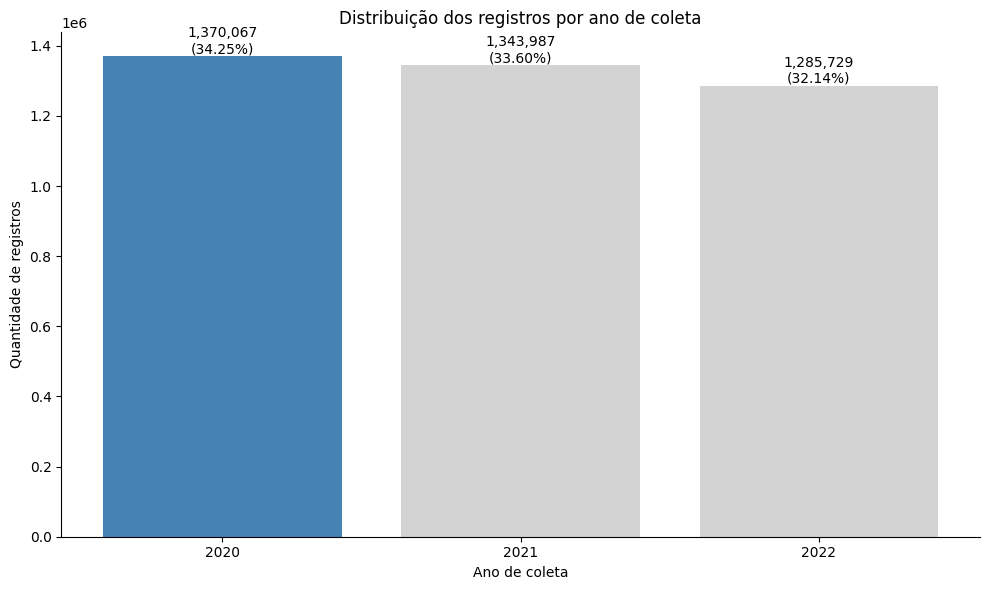

In [51]:
from pyspark.sql.functions import col, count
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# DISTRIBUIÇÃO DOS REGISTROS POR ANO DE COLETA
# ============================================================

distribuicao_ano = (
    df_sinasc
    .groupBy("ANO_COLETA")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(col("REGISTROS").desc())
)

# Traz somente as 3 linhas agregadas para o Pandas
df_ano = distribuicao_ano.toPandas()

# Calcula o percentual
df_ano["PERCENTUAL"] = (
    df_ano["REGISTROS"] / df_ano["REGISTROS"].sum() * 100
)

# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Destaca o primeiro ano (maior quantidade)
cores = ["steelblue"] + ["lightgray"] * (len(df_ano) - 1)

barras = ax.bar(
    df_ano["ANO_COLETA"],
    df_ano["REGISTROS"],
    color=cores
)

ax.set_title("Distribuição dos registros por ano de coleta")
ax.set_xlabel("Ano de coleta")
ax.set_ylabel("Quantidade de registros")

# Rótulos com quantidade absoluta e percentual
for barra, registros, percentual in zip(
    barras,
    df_ano["REGISTROS"],
    df_ano["PERCENTUAL"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{registros:,}\n({percentual:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Lógica utilizada:** A partir da base **principal (df_sinasc)**, realizei no Spark a agregação dos registros por ANO_COLETA e o cálculo das respectivas frequências. O resultado resumido foi então convertido para Pandas, onde calculei os percentuais e utilizei o Matplotlib para gerar o gráfico.

**Resultado:** A distribuição dos registros por ano de coleta apresenta um comportamento relativamente equilibrado entre os três anos analisados. O ano de 2020 concentra a maior quantidade de registros, com 1.370.067 registros (34,25%), seguido de 2021, com 1.343.987 (33,60%), e 2022, com 1.285.729 (32,14%). Apesar de 2020 apresentar a maior participação, a diferença entre os anos é pequena, indicando que os registros estão distribuídos de forma bastante próxima entre 2020 e 2022.


### Pergunta 2 - Mostre a distribuição dos registros pelo estado em que foram coletados os dados. Qual estado está em quarto lugar nesse ranking? E qual sua frequência?

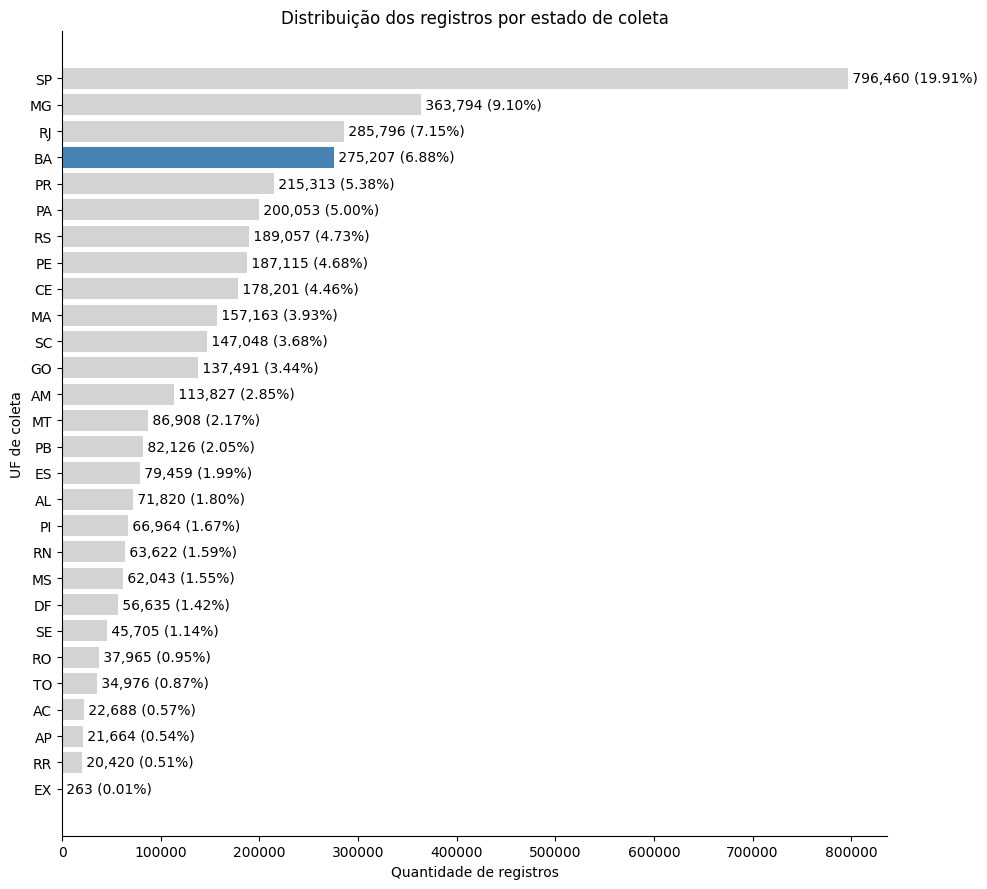

In [52]:
distribuicao_uf = (
    df_sinasc
    .groupBy("UF_COLETA")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(col("REGISTROS").desc())
)

# Traz somente os dados agregados para o Pandas
df_uf = distribuicao_uf.toPandas()

# Calcula o percentual
df_uf["PERCENTUAL"] = (
    df_uf["REGISTROS"] / df_uf["REGISTROS"].sum() * 100
)

# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 9))

# Destaca o 4º colocado
cores = [
    "steelblue" if i == 3 else "lightgray"
    for i in range(len(df_uf))
]

barras = ax.barh(
    df_uf["UF_COLETA"],
    df_uf["REGISTROS"],
    color=cores
)

# Maior estado no topo
ax.invert_yaxis()

ax.set_title("Distribuição dos registros por estado de coleta")
ax.set_xlabel("Quantidade de registros")
ax.set_ylabel("UF de coleta")

# Rótulos com frequência e percentual
for barra, registros, percentual in zip(
    barras,
    df_uf["REGISTROS"],
    df_uf["PERCENTUAL"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {registros:,} ({percentual:.2f}%)",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [53]:
print(
    f"4º lugar: {df_uf.iloc[3]['UF_COLETA']} — "
    f"{df_uf.iloc[3]['REGISTROS']:,} registros "
    f"({df_uf.iloc[3]['PERCENTUAL']:.2f}%)"
)

4º lugar: BA — 275,207 registros (6.88%)


**Lógica utilizada:** Seguindo o mesmo fluxo, realizei no Spark a agregação dos registros por UF_COLETA e o cálculo das frequências. O resultado foi convertido para Pandas para o cálculo dos percentuais e utilizado no Matplotlib para apresentar o ranking das UFs.

**Resultado:** A Bahia ocupa a quarta posição no ranking, com 275.207 registros, correspondentes a 6,88% do total de 3.999.783 registros analisados.

### Pergunta 3 - Qual a distribuição dos estados de nascimento? Mostre o nome do estado, a frequência e a porcentagem em relação a base.

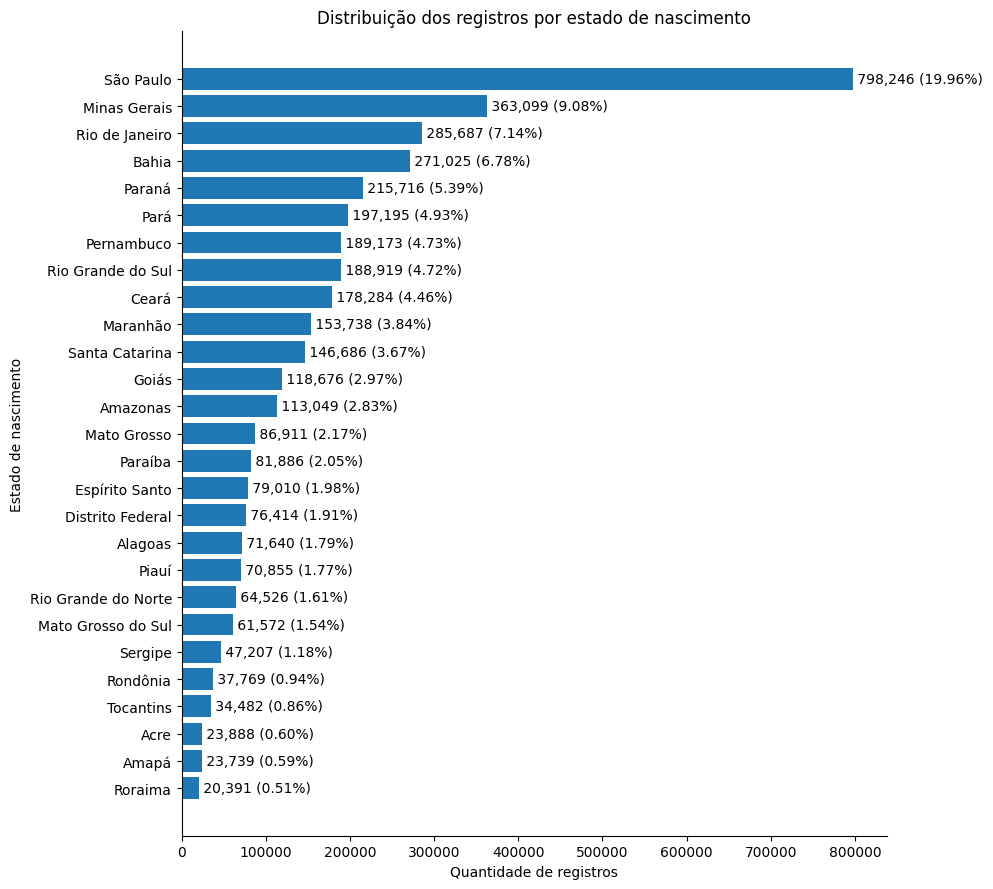

In [54]:
distribuicao_estado_nascimento = (
    df_sinasc
    .groupBy("NOME_UF_NASC")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(col("REGISTROS").desc())
)

df_estado_nascimento = distribuicao_estado_nascimento.toPandas()

df_estado_nascimento["PERCENTUAL"] = (
    df_estado_nascimento["REGISTROS"]
    / df_estado_nascimento["REGISTROS"].sum()
    * 100
)

fig, ax = plt.subplots(figsize=(10, 9))

barras = ax.barh(
    df_estado_nascimento["NOME_UF_NASC"],
    df_estado_nascimento["REGISTROS"]
)

ax.invert_yaxis()

ax.set_title("Distribuição dos registros por estado de nascimento")
ax.set_xlabel("Quantidade de registros")
ax.set_ylabel("Estado de nascimento")

for barra, registros, percentual in zip(
    barras,
    df_estado_nascimento["REGISTROS"],
    df_estado_nascimento["PERCENTUAL"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {registros:,} ({percentual:.2f}%)",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Lógica utilizada:** Seguindo o mesmo fluxo das questões anteriores, agrupei os registros no Spark por `NOME_UF_NASC`, contabilizei a frequência de cada estado e calculei sua participação percentual em relação ao total da base. O resultado agregado foi convertido para Pandas para apresentação no gráfico no Matplotlib.

**Resultado:** São Paulo apresenta a maior quantidade de registros de nascimento, com 798.246 registros (19,96%), seguido por Minas Gerais, com 363.099 (9,08%), e Rio de Janeiro, com 285.687 (7,14%). A Bahia aparece na quarta posição, com 271.025 registros (6,78%).

A distribuição apresenta um comportamento bastante semelhante ao observado para o estado de coleta dos dados, com São Paulo, Minas Gerais, Rio de Janeiro e Bahia também concentrando as maiores frequências. Esse padrão é coerente com a concentração populacional desses estados e mostra que, na base analisada, os registros de nascimento estão fortemente concentrados nas UFs com maior população.


### Pergunta - 4 Quais são os cinco estados com maior número de nascidos, em que o município de residência é o mesmo do município de nascimento? Mostre os nomes dos estados e a frequência.

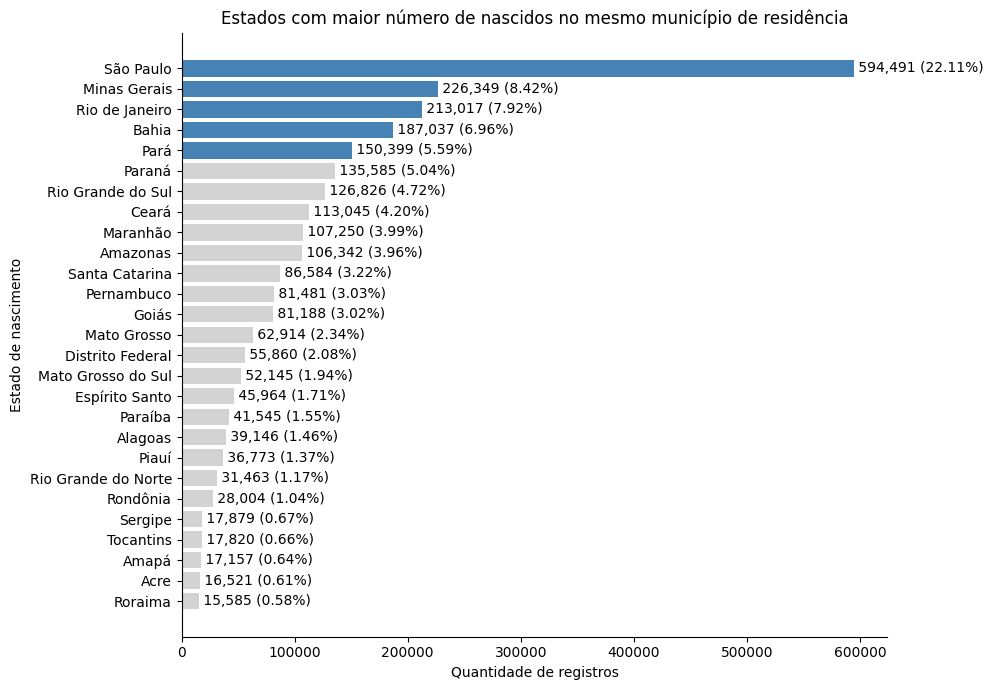

In [55]:
distribuicao_municipio = (
    df_sinasc
    .filter(
        col("CODMUNNASC").isNotNull() &
        col("CODMUNRES").isNotNull() &
        (col("CODMUNNASC") == col("CODMUNRES"))
    )
    .groupBy("NOME_UF_NASC")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(col("REGISTROS").desc())
)

df_municipio = distribuicao_municipio.toPandas()

df_municipio["PERCENTUAL"] = (
    df_municipio["REGISTROS"]
    / df_municipio["REGISTROS"].sum()
    * 100
)

df_top5 = df_municipio.head(5)

fig, ax = plt.subplots(figsize=(10, 7))

cores = [
    "steelblue" if i < 5 else "lightgray"
    for i in range(len(df_municipio))
]

barras = ax.barh(
    df_municipio["NOME_UF_NASC"],
    df_municipio["REGISTROS"],
    color=cores
)

ax.invert_yaxis()

ax.set_title(
    "Estados com maior número de nascidos no mesmo município de residência"
)
ax.set_xlabel("Quantidade de registros")
ax.set_ylabel("Estado de nascimento")

for barra, registros, percentual in zip(
    barras,
    df_municipio["REGISTROS"],
    df_municipio["PERCENTUAL"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {registros:,} ({percentual:.2f}%)",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Lógica utilizada:** Para identificar os estados com maior número de nascidos no mesmo município de residência, primeiro filtrei a base no **Spark**, mantendo apenas os registros em que `CODMUNNASC` e `CODMUNRES` possuem o mesmo código. Também desconsiderei registros sem informação em algum dos dois códigos, pois não seria possível determinar essa correspondência. Em seguida, ainda no **Spark**, agrupei os registros por `NOME_UF_NASC`, contabilizei a frequência de cada estado e ordenei os resultados de forma decrescente. O resultado dessa agregação foi então convertido para **Pandas**, onde calculei a participação percentual de cada estado em relação ao conjunto de registros que atende ao critério e selecionei os cinco estados com maior frequência. Por fim, utilizei o **Matplotlib** para apresentar graficamente os resultados, destacando os cinco primeiros e exibindo a frequência e o percentual nos rótulos.


**Resultado:** Os cinco estados com maior número de nascidos no mesmo município de residência são:

1. **São Paulo:** 594.491 registros (22,11%)
2. **Minas Gerais:** 226.349 registros (8,42%)
3. **Rio de Janeiro:** 213.017 registros (7,92%)
4. **Bahia:** 187.037 registros (6,96%)
5. **Pará:** 150.399 registros (5,59%)

São Paulo apresenta uma frequência bastante superior aos demais estados, concentrando 22,11% dos registros que atendem ao critério analisado. Minas Gerais e Rio de Janeiro aparecem na sequência, enquanto Bahia e Pará completam os cinco primeiros estados.


### Pergunta - 5 Dentro da UF com maior número de nascidos, qual município possui o maior número de nascidos? Mostre o nome do estado e município e seus respectivos valores.

In [56]:
# 1. Identifica a UF com maior número de nascidos
uf_maior_nascimentos = (
    df_sinasc
    .groupBy("NOME_UF_NASC")
    .agg(
        count("*").alias("REGISTROS_UF")
    )
    .orderBy(col("REGISTROS_UF").desc())
    .limit(1)
)

df_uf_maior = uf_maior_nascimentos.toPandas()

nome_uf = df_uf_maior.loc[0, "NOME_UF_NASC"]
registros_uf = df_uf_maior.loc[0, "REGISTROS_UF"]


# 2. Dentro da UF, identifica o município com maior número de nascidos
municipio_maior = (
    df_sinasc
    .filter(
        (col("NOME_UF_NASC") == nome_uf) &
        col("NOME_MUNIC_NASC").isNotNull()
    )
    .groupBy("NOME_MUNIC_NASC")
    .agg(
        count("*").alias("REGISTROS_MUNICIPIO")
    )
    .orderBy(col("REGISTROS_MUNICIPIO").desc())
    .limit(1)
)


# 3. Converte o resultado agregado para Pandas
df_municipio_top = municipio_maior.toPandas()


# 4. Calcula o percentual do município dentro da UF
df_municipio_top["PERCENTUAL"] = (
    df_municipio_top["REGISTROS_MUNICIPIO"]
    / registros_uf
    * 100
)


# 5. Adiciona as informações da UF à tabela final
df_municipio_top.insert(0, "NOME_UF_NASC", nome_uf)
df_municipio_top.insert(1, "REGISTROS_UF", registros_uf)


# 6. Organiza as colunas
df_municipio_top = df_municipio_top[
    [
        "NOME_UF_NASC",
        "REGISTROS_UF",
        "NOME_MUNIC_NASC",
        "REGISTROS_MUNICIPIO",
        "PERCENTUAL"
    ]
]

df_municipio_top

,NOME_UF_NASC,REGISTROS_UF,NOME_MUNIC_NASC,REGISTROS_MUNICIPIO,PERCENTUAL
0,São Paulo,798246,São Paulo,234000,29.314272


**Lógica utilizada:** Primeiro, no **Spark**, agrupei os registros por `NOME_UF_NASC`, contabilizei a frequência de cada estado e ordenei os resultados de forma decrescente para identificar a UF com maior número de nascidos. Em seguida, filtrei a base para essa UF e agrupei os registros por `NOME_MUNIC_NASC`, novamente contabilizando e ordenando as frequências para identificar o município com maior número de nascidos. Os resultados agregados foram convertidos para **Pandas**, onde calculei a participação percentual do município em relação ao total de nascimentos da UF e organizei as informações da UF e do município em uma tabela final.

**Resultado:** A UF com maior número de nascidos é **São Paulo**, com **798.246 registros**. Dentro dessa UF, o município com maior número de nascidos também é **São Paulo**, com **234.000 registros**, correspondentes a **29,31%** dos nascimentos registrados no estado.


### Pergunta - 6 Quais os dez estados em que nasceram mais indígenas, cujo local de nascimento foi em domicílio ou em hospital no ano de 2020? Mostre os nomes dos Estados, a frequência e o percentual em relação ao total de indígenas nascidos no Brasil em 2020.

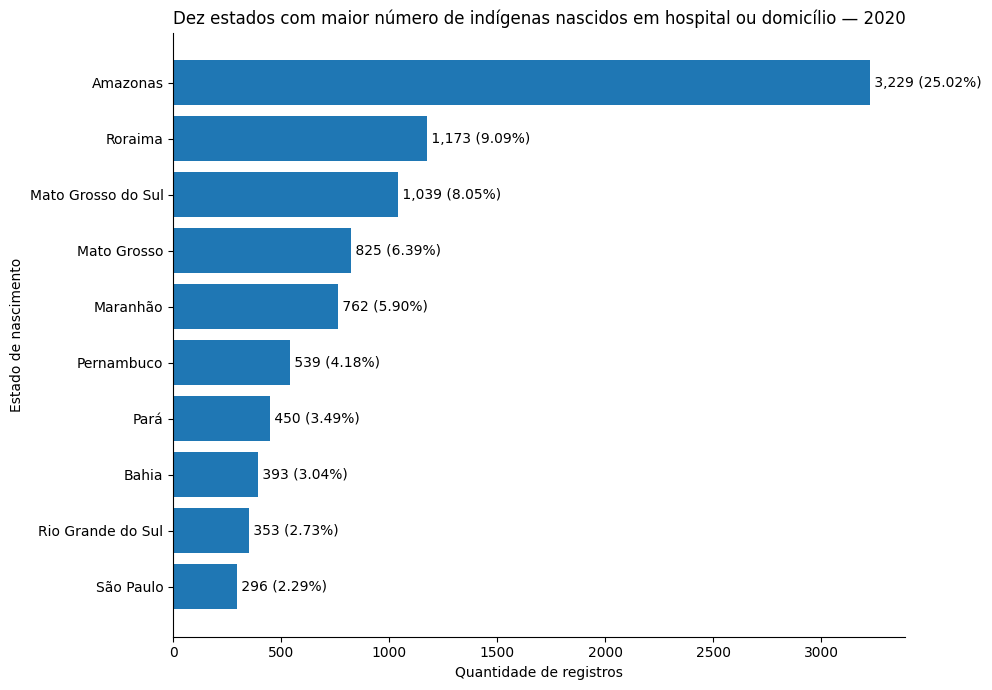

In [57]:
# 1. Total de indígenas nascidos no Brasil em 2020
#    Usado como denominador do percentual
total_indigenas_2020 = (
    df_sinasc
    .filter(
        (col("ANO_COLETA") == "2020") &
        (col("RACACOR") == "Indígena")
    )
    .count()
)

# 2. Estados com maior número de indígenas nascidos
#    considerando apenas nascimento em hospital ou domicílio
distribuicao_indigenas = (
    df_sinasc
    .filter(
        (col("ANO_COLETA") == "2020") &
        (col("RACACOR") == "Indígena") &
        col("NOME_UF_NASC").isNotNull() &
        col("LOCNASC").isin("Hospital", "Domicílio")
    )
    .groupBy("NOME_UF_NASC")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(
        col("REGISTROS").desc()
    )
)

# 3. Converte o resultado agregado para Pandas
df_indigenas = distribuicao_indigenas.toPandas()

# 4. Calcula o percentual em relação ao total de indígenas de 2020
df_indigenas["PERCENTUAL"] = (
    df_indigenas["REGISTROS"]
    / total_indigenas_2020
    * 100
)

# 5. Seleciona os dez estados com maior frequência
df_top10_indigenas = df_indigenas.head(10)

# 6. Gráfico dos dez estados
fig, ax = plt.subplots(figsize=(10, 7))

barras = ax.barh(
    df_top10_indigenas["NOME_UF_NASC"],
    df_top10_indigenas["REGISTROS"]
)

ax.invert_yaxis()

ax.set_title(
    "Dez estados com maior número de indígenas nascidos em hospital ou domicílio — 2020"
)
ax.set_xlabel("Quantidade de registros")
ax.set_ylabel("Estado de nascimento")

for barra, registros, percentual in zip(
    barras,
    df_top10_indigenas["REGISTROS"],
    df_top10_indigenas["PERCENTUAL"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {registros:,} ({percentual:.2f}%)",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Lógica utilizada:** Primeiro, no **Spark**, filtrei os registros referentes ao ano de 2020 e selecionei os registros classificados como `"Indígena"` em `RACACOR`. Para identificar os estados solicitados, considerei apenas os nascimentos ocorridos em `"Hospital"` ou `"Domicílio"`, agrupei os registros por `NOME_UF_NASC` e contabilizei a frequência de cada estado, ordenando os resultados de forma decrescente. Também calculei no Spark o total de indígenas nascidos no Brasil em 2020, independentemente do local de nascimento, que foi utilizado como denominador para o cálculo do percentual. O resultado agregado foi convertido para **Pandas**, onde calculei o percentual de cada estado em relação ao total de indígenas nascidos no Brasil em 2020 e selecionei os dez estados com maior frequência. Por fim, utilizei o **Matplotlib** para apresentar os resultados graficamente.

**Resultado:** Amazonas apresenta a maior frequência, com **3.229 registros**, correspondentes a **25,02%** do total de indígenas nascidos no Brasil em 2020. Em seguida aparecem Roraima, com **1.173 registros (9,09%)**, Mato Grosso do Sul, com **1.039 (8,05%)**, Mato Grosso, com **825 (6,39%)** e Maranhão, com **762 (5,90%)**. Completam os dez estados Pernambuco (**539; 4,18%**), Pará (**450; 3,49%**), Bahia (**393; 3,04%**), Rio Grande do Sul (**353; 2,73%**) e São Paulo (**296; 2,29%**).


### Pergunta - 7 Qual a quantidade de nascidos negros (pretos e pardos) por parto cesáreo, filhos de mães solteiras, que tiveram pelo menos quatro consultas de pré-natal? Mostre a distribuição e informe o valor total de nascidos negros

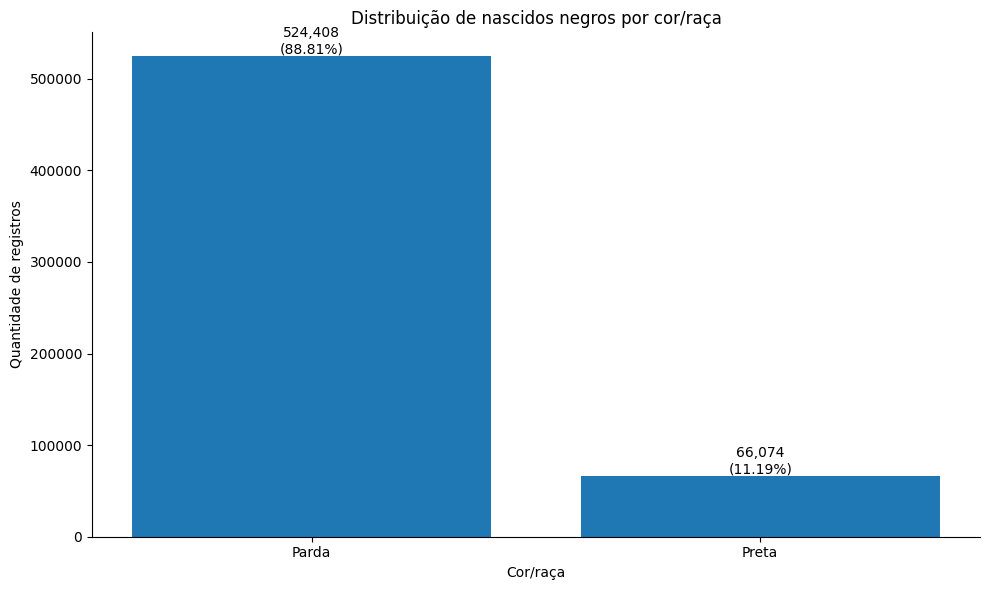

In [81]:
# 1. Filtra os registros que atendem a todos os critérios
nascidos_negros = (
    df_sinasc
    .filter(
        col("RACACOR").isin("Preta", "Parda") &
        (col("PARTO") == "Cesárea") &
        (col("ESTCIVMAE") == "Solteira") &
        col("CONSULTAS").isin("4 a 6", "7 e mais")
    )
)

# 2. Distribuição dos nascidos negros por cor/raça
distribuicao_negros = (
    nascidos_negros
    .groupBy("RACACOR")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(col("REGISTROS").desc())
)

# 3. Converte o resultado agregado para Pandas
df_negros = distribuicao_negros.toPandas()

# 4. Calcula o total de nascidos negros
total_negros = df_negros["REGISTROS"].sum()

# 5. Calcula o percentual de cada categoria dentro do total
df_negros["PERCENTUAL"] = (
    df_negros["REGISTROS"]
    / total_negros
    * 100
)

# 6. Gráfico da distribuição
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(
    df_negros["RACACOR"],
    df_negros["REGISTROS"]
)

ax.set_title(
    "Distribuição de nascidos negros por cor/raça"
)
ax.set_xlabel("Cor/raça")
ax.set_ylabel("Quantidade de registros")

for barra, registros, percentual in zip(
    barras,
    df_negros["REGISTROS"],
    df_negros["PERCENTUAL"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{registros:,}\n({percentual:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



In [82]:
# 7. Tabela final
print(f"Total de Nascidos Negros: {df_negros['REGISTROS'].sum():,}")

Total de Nascidos Negros: 590,482


**Lógica utilizada:** Primeiro, no **Spark**, filtrei os registros que atendem simultaneamente aos critérios definidos: `RACACOR` igual a `"Preta"` ou `"Parda"`, `PARTO` igual a `"Cesárea"`, `ESTCIVMAE` igual a `"Solteira"` e `CONSULTAS` igual a `"4 a 6"` ou `"7 ou mais"`, representando pelo menos quatro consultas de pré-natal. Em seguida, agrupei os registros por `RACACOR` para obter a distribuição entre pretos e pardos. O resultado agregado foi convertido para **Pandas**, onde calculei a participação percentual de cada categoria em relação ao total de nascidos negros. Por fim, utilizei o **Matplotlib** para apresentar graficamente essa distribuição.

**Resultado:** Foram identificados **590.482 nascidos negros** que atendem simultaneamente a todos os critérios da questão. Desse total, **524.408 (88,81%)** são classificados como pardos e **66.074 (11,19%)** como pretos. Portanto, a maior parte dos registros do grupo analisado corresponde à categoria parda.


### Pergunta - 8 Quantos municípios aparecem em cada Estado de nascimento? Mostre os nomes dos estados de nascimento, a frequência e a porcentagem em relação a base.

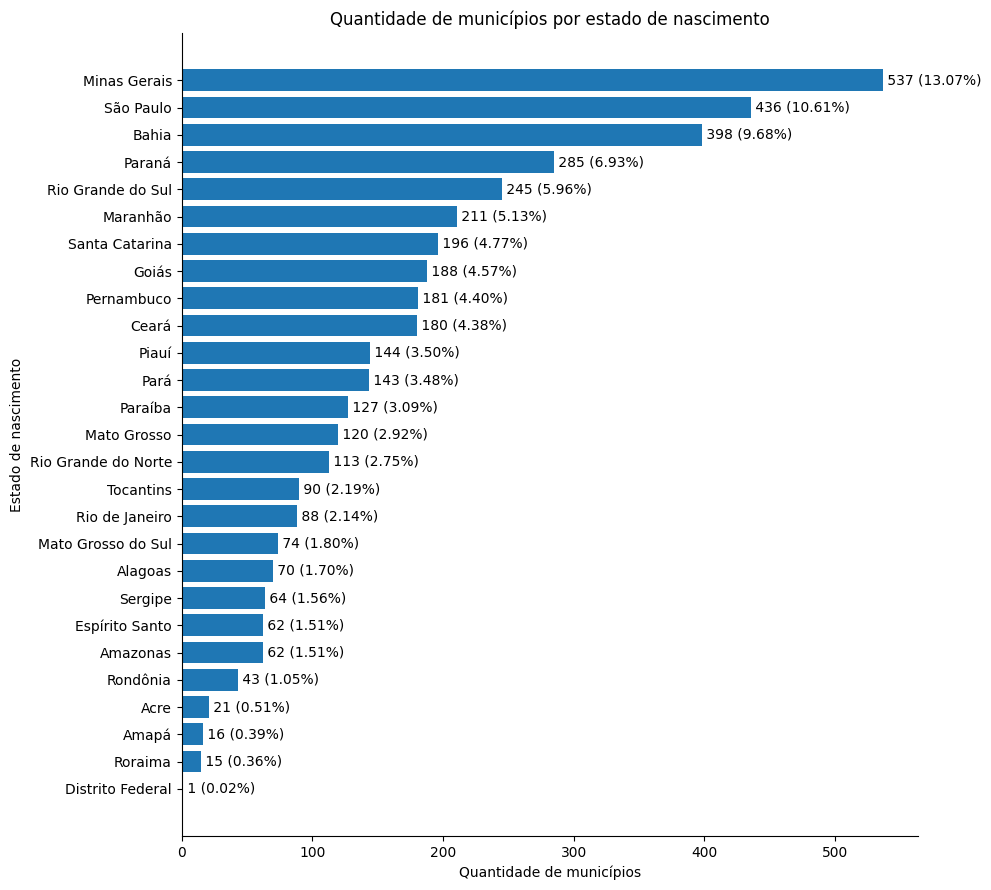

In [60]:
from pyspark.sql.functions import col, countDistinct
# 1. Conta os municípios distintos por estado de nascimento
distribuicao_municipios = (
    df_sinasc
    .filter(
        col("NOME_UF_NASC").isNotNull() &
        col("NOME_MUNIC_NASC").isNotNull()
    )
    .groupBy("NOME_UF_NASC")
    .agg(
        countDistinct("NOME_MUNIC_NASC").alias("MUNICIPIOS")
    )
    .orderBy(
        col("MUNICIPIOS").desc()
    )
)

# 2. Converte o resultado agregado para Pandas
df_municipios = distribuicao_municipios.toPandas()

# 3. Calcula o percentual em relação ao total de municípios
df_municipios["PERCENTUAL"] = (
    df_municipios["MUNICIPIOS"]
    / df_municipios["MUNICIPIOS"].sum()
    * 100
)

# 4. Gráfico
fig, ax = plt.subplots(figsize=(10, 9))

barras = ax.barh(
    df_municipios["NOME_UF_NASC"],
    df_municipios["MUNICIPIOS"]
)

ax.invert_yaxis()

ax.set_title(
    "Quantidade de municípios por estado de nascimento"
)
ax.set_xlabel("Quantidade de municípios")
ax.set_ylabel("Estado de nascimento")

for barra, municipios, percentual in zip(
    barras,
    df_municipios["MUNICIPIOS"],
    df_municipios["PERCENTUAL"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {municipios:,} ({percentual:.2f}%)",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Lógica utilizada:** Primeiro, no **Spark**, considerei apenas os registros com estado e município de nascimento identificados e agrupei os dados por `NOME_UF_NASC`. Para cada estado, contabilizei a quantidade de municípios distintos por meio de `countDistinct("NOME_MUNIC_NASC")`. O resultado agregado foi convertido para **Pandas**, onde calculei o percentual de cada estado em relação ao total de municípios contabilizados na distribuição e organizei os resultados para apresentação. Por fim, utilizei o **Matplotlib** para apresentar graficamente a quantidade de municípios por estado, com suas respectivas frequências e percentuais.

**Resultado:** Minas Gerais apresenta a maior quantidade de municípios de nascimento identificados, com **537 municípios (13,07%)**, seguido por São Paulo, com **436 (10,61%)**, e Bahia, com **398 (9,68%)**. Paraná aparece em seguida, com **285 municípios (6,93%)**, seguido pelo Rio Grande do Sul, com **245 (5,96%)**. Ao todo, foram identificados **4.115 municípios** na distribuição apresentada.


### Pergunta 9 Quantos registros têm os mesmos valores de idade da mãe nas variáveis ‘IDADE_MAE_CRIADA’ e ‘IDADEMAE’?

In [61]:
# 1. Seleciona os registros em que as duas idades são iguais
idade_igual = (
    df_sinasc
    .filter(
        col("IDADE_MAE_CRIADA").isNotNull() &
        col("IDADEMAE").isNotNull() &
        (col("IDADE_MAE_CRIADA") == col("IDADEMAE"))
    )
)

# 2. Conta a quantidade de registros
total_idade_igual = idade_igual.count()

print(f"Total de registros com idade da mãe igual: {total_idade_igual:,}")

Total de registros com idade da mãe igual: 3,959,270


**Lógica utilizada:** No **Spark**, comparei os valores das variáveis `IDADE_MAE_CRIADA` e `IDADEMAE` registro a registro, considerando apenas os casos em que ambas as variáveis possuem informação. Em seguida, filtrei os registros em que os dois valores são exatamente iguais e realizei a contagem desses registros. Como a questão solicita apenas a quantidade de registros que atende ao critério, não houve necessidade de realizar uma agregação para **Pandas** ou utilizar o **Matplotlib** para visualização.

**Resultado:** Foram identificados **3.959.270 registros** em que a idade da mãe calculada na variável `IDADE_MAE_CRIADA` é igual ao valor informado originalmente em `IDADEMAE`.


### Pergunta - 10 Quais são as três menores e as três maiores idades das mães, com base na variável criada: ‘IDADE_MAE_CRIADA’?

In [62]:
# 1. Seleciona os valores válidos e distintos de idade da mãe
idades_mae = (
    df_sinasc
    .filter(col("IDADE_MAE_CRIADA").isNotNull())
    .select("IDADE_MAE_CRIADA")
    .distinct()
)

# 2. Três menores idades
menores_idades = (
    idades_mae
    .orderBy(col("IDADE_MAE_CRIADA").asc())
    .limit(3)
)

# 3. Três maiores idades
maiores_idades = (
    idades_mae
    .orderBy(col("IDADE_MAE_CRIADA").desc())
    .limit(3)
)

print("Três menores idades:")
menores_idades.show()

print("Três maiores idades:")
maiores_idades.show()

Três menores idades:
+----------------+
|IDADE_MAE_CRIADA|
+----------------+
|              -1|
|               0|
|               8|
+----------------+

Três maiores idades:
+----------------+
|IDADE_MAE_CRIADA|
+----------------+
|            1823|
|            1820|
|            1042|
+----------------+



In [63]:
# 1. Seleciona os valores válidos e distintos de idade da mãe
idades_mae = (
    df_sinasc
    .filter(col("IDADEMAE").isNotNull())
    .select("IDADEMAE")
    .distinct()
)

# 2. Três menores idades
menores_idades_outra = (
    idades_mae
    .orderBy(col("IDADEMAE").asc())
    .limit(3)
)

# 3. Três maiores idades
maiores_idades_outra = (
    idades_mae
    .orderBy(col("IDADEMAE").desc())
    .limit(3)
)

print("Três menores idades:")
menores_idades_outra.show()

print("Três maiores idades:")
maiores_idades_outra.show()

Três menores idades:
+--------+
|IDADEMAE|
+--------+
|       8|
|      10|
|      11|
+--------+

Três maiores idades:
+--------+
|IDADEMAE|
+--------+
|      99|
|      65|
|      64|
+--------+



In [64]:
df_sinasc.select(
    "DTNASC",
    "DTNASCMAE",
    "IDADEMAE",
    "IDADE_MAE_CRIADA"
).filter(
    col("IDADE_MAE_CRIADA") < 0
).show(50, truncate=False)

+--------+---------+--------+----------------+
|DTNASC  |DTNASCMAE|IDADEMAE|IDADE_MAE_CRIADA|
+--------+---------+--------+----------------+
|17072020|18072020 |29      |-1              |
|06042022|07042022 |32      |-1              |
|06062021|14062021 |18      |-1              |
|23032020|28042020 |17      |-1              |
|27102021|28102021 |41      |-1              |
|07032020|09032020 |26      |-1              |
|26102022|07112022 |33      |-1              |
|08012020|12022020 |20      |-1              |
|22082020|26082020 |19      |-1              |
|01032021|12032021 |30      |-1              |
|03022022|09022022 |19      |-1              |
|14122020|17122020 |31      |-1              |
|20042021|29042021 |31      |-1              |
|25092022|21102022 |19      |-1              |
|04042020|16042020 |19      |-1              |
|18082020|26082020 |25      |-1              |
|13072022|15072022 |19      |-1              |
+--------+---------+--------+----------------+



In [65]:
df_sinasc.select(
    "DTNASC",
    "DTNASCMAE",
    "IDADEMAE",
    "IDADE_MAE_CRIADA"
).filter(
    col("IDADE_MAE_CRIADA") > 150
).orderBy(
    col("IDADE_MAE_CRIADA")
).show(50, truncate=False)

+--------+---------+--------+----------------+
|DTNASC  |DTNASCMAE|IDADEMAE|IDADE_MAE_CRIADA|
+--------+---------+--------+----------------+
|12112021|22011199 |29      |822             |
|10012020|21100998 |21      |1021            |
|12122020|21110999 |21      |1021            |
|03012022|19110999 |22      |1022            |
|07112021|11110998 |23      |1022            |
|22112022|28110999 |23      |1022            |
|27052021|27110998 |23      |1022            |
|24032022|23110999 |23      |1022            |
|25082021|24110997 |24      |1023            |
|29122021|29110998 |23      |1023            |
|16062020|31100996 |24      |1023            |
|26102021|16110996 |25      |1024            |
|16062021|21110996 |25      |1024            |
|22022021|17110996 |25      |1024            |
|29032022|10110997 |25      |1024            |
|10092022|11110997 |25      |1024            |
|31102021|21010995 |26      |1026            |
|12122021|11110995 |26      |1026            |
|18042022|301

**Lógica utilizada:** No **Spark**, selecionei os valores não nulos e distintos da variável `IDADE_MAE_CRIADA`. Em seguida, ordenei os valores de forma crescente e decrescente e selecionei os três menores e os três maiores valores. Como a questão solicita apenas a identificação desses valores, não houve necessidade de realizar uma agregação para **Pandas** ou utilizar o **Matplotlib**.

**Resultado:** As três menores idades identificadas foram **-1, 0 e 8 anos**. As três maiores foram **1.823, 1.820 e 1.042 anos**.

**Observação sobre a qualidade dos dados:** Os valores extremos identificados foram investigados individualmente, comparando `DTNASC`, `DTNASCMAE` e `IDADEMAE`. A investigação mostrou que os valores inconsistentes da `IDADE_MAE_CRIADA` estão associados a registros com datas de nascimento da mãe aparentemente incorretas. Por exemplo, foram identificados registros em que `DTNASCMAE` ocorre após `DTNASC`, produzindo idade negativa, embora `IDADEMAE` apresente um valor plausível. Também foram encontrados registros em que o ano de nascimento da mãe foi informado de forma incorreta, como `22011199`, `21100998` e `09070200`, resultando em idades calculadas de **822, 1.021 e 1.820 anos**, respectivamente. Esses casos indicam inconsistências no preenchimento de `DTNASCMAE`. Não foi realizada uma reconstrução ou imputação dessas datas com base na `IDADEMAE`; as ocorrências foram mantidas e **registradas e documentadas como inconsistências identificadas na base**.


In [66]:
from pyspark.sql.functions import col, min, max, avg, count, countDistinct

variaveis_numericas = [
    "PESO",
    "IDADEMAE",
    "IDADE_MAE_CRIADA",
    "SEMAGESTAC",
    "CONSPRENAT",
    "CODESTAB"
]

resumo_numerico = []

for c in variaveis_numericas:
    resultado = (
        df_sinasc
        .select(
            count(col(c)).alias("NAO_NULOS"),
            countDistinct(col(c)).alias("DISTINTOS"),
            min(col(c)).alias("MIN"),
            max(col(c)).alias("MAX"),
            avg(col(c)).alias("MEDIA")
        )
        .collect()[0]
    )

    resumo_numerico.append((
        c,
        resultado["NAO_NULOS"],
        resultado["DISTINTOS"],
        resultado["MIN"],
        resultado["MAX"],
        resultado["MEDIA"]
    ))

for linha in resumo_numerico:
    print(linha)

('PESO', 3998983, 5030, 3, 7000, 3176.1296039518047)
('IDADEMAE', 3999731, 58, 8, 99, 27.34335684074754)
('IDADE_MAE_CRIADA', 3959921, 81, -1, 1823, 27.365479260823637)
('SEMAGESTAC', 3954308, 27, 19, 45, 38.40555212188833)
('CONSPRENAT', 3925930, 68, 0, 99, 8.751563578566097)
('CODESTAB', 3958080, 6250, 20, 9999999, 2955060.248128638)


# Observação sobre a qualidade dos dados

Durante a inspeção das variáveis numéricas, foram verificados os valores mínimos, máximos e a quantidade de valores distintos. Além das inconsistências identificadas na `IDADE_MAE_CRIADA`, foram observados alguns valores extremos que merecem ser registrados para fins de qualidade dos dados. A variável `PESO`, por exemplo, apresenta valores entre **3 e 7.000 gramas**, enquanto `IDADEMAE` varia de **8 a 99 anos** e `CONSPRENAT` apresenta valores entre **0 e 99 consultas**. Esses valores podem representar registros extremos ou possíveis inconsistências da fonte, mas a análise dos limites, isoladamente, não é suficiente para classificá-los como erros. Por esse motivo, os valores foram mantidos sem alteração e as ocorrências foram registradas como pontos de atenção na avaliação da qualidade da base.


### Pergunta - 11 Mostre a distribuição da variável criada com o comprimento do campo ‘PESO’.

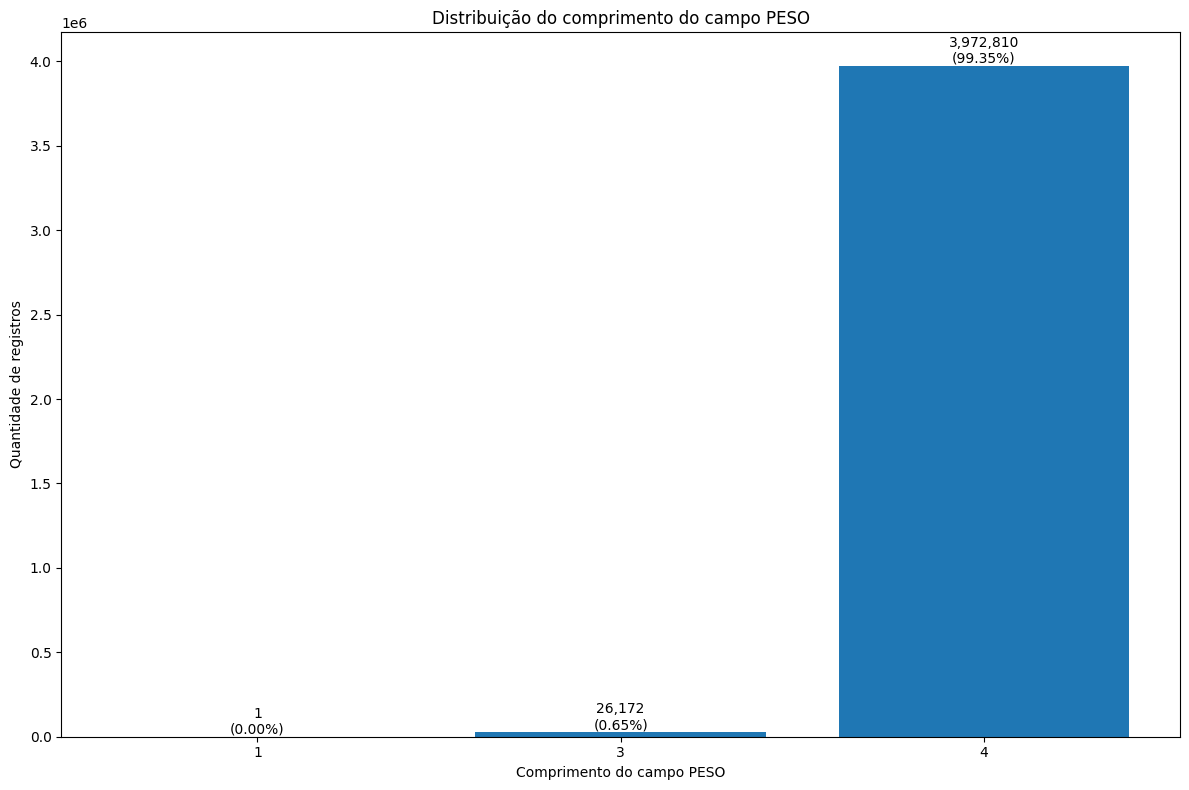

In [67]:
distribuicao_comprimento_peso = (
    df_sinasc
    .filter(col("COMPRIMENTO_PESO").isNotNull())
    .groupBy("COMPRIMENTO_PESO")
    .agg(count("*").alias("REGISTROS"))
    .orderBy(col("COMPRIMENTO_PESO"))
)

df_comprimento_peso = distribuicao_comprimento_peso.toPandas()

df_comprimento_peso["PERCENTUAL"] = (
    df_comprimento_peso["REGISTROS"]
    / df_comprimento_peso["REGISTROS"].sum()
    * 100
)


plt.figure(figsize=(12, 8))

barras = plt.bar(
    df_comprimento_peso["COMPRIMENTO_PESO"].astype(str),
    df_comprimento_peso["REGISTROS"]
)

plt.xlabel("Comprimento do campo PESO")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição do comprimento do campo PESO")

for barra, registros, percentual in zip(
    barras,
    df_comprimento_peso["REGISTROS"],
    df_comprimento_peso["PERCENTUAL"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{registros:,}\n({percentual:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [68]:
df_comprimento_peso

,COMPRIMENTO_PESO,REGISTROS,PERCENTUAL
0,1,1,0.000025
1,3,26172,0.654466
2,4,3972810,99.345509


**Lógica utilizada:** No **Spark**, agrupei os registros pelo valor de `COMPRIMENTO_PESO` e contabilizei a quantidade de ocorrências em cada comprimento. O resultado agregado foi convertido para **Pandas**, onde calculei o percentual de cada categoria em relação ao total de registros com `COMPRIMENTO_PESO` preenchido. Por fim, utilizei o **Matplotlib** para apresentar graficamente a distribuição, com a frequência e o percentual de cada comprimento.

**Resultado:** A maior parte dos registros possui `PESO` com **4 dígitos**, representando **3.972.810 registros (99,35%)**. Em seguida, aparecem os valores com **3 dígitos**, com **26.172 registros (0,65%)**, e os valores com **1 dígito**, com **1 registro (0,000025%)**.


### Pergunta - 12 Quantos bebês nasceram com menos de 2000 gramas? Qual a porcentagem desse valor considerando o tamanho da base?

In [69]:
bebes_menos_2000 = (
    df_sinasc
    .filter(
        col("PESO").isNotNull() &
        (col("PESO") < 2000)
    )
)

total_menos_2000 = bebes_menos_2000.count()
total_base = df_sinasc.count()

percentual_menos_2000 = total_menos_2000 / total_base * 100

print(f"Bebês com menos de 2000g: {total_menos_2000:,}")
print(f"Percentual da base: {percentual_menos_2000:.2f}%")

Bebês com menos de 2000g: 125,546
Percentual da base: 3.14%


**Lógica utilizada:** No **Spark**, filtrei os registros em que `PESO` está preenchido e apresenta valor inferior a 2.000 gramas. Em seguida, realizei a contagem desses registros e comparei o resultado com o total de registros da base para calcular o percentual correspondente. Como a questão solicita apenas uma contagem e seu percentual em relação ao total da base, o resultado já é simples e direto, não sendo necessária uma etapa de agregação para **Pandas** nem a utilização do **Matplotlib** para visualização.

**Resultado:** Foram identificados **125.546 bebês** com peso inferior a **2.000 gramas**, correspondendo a **3,14%** do total de registros da base analisada.


### Pergunta - 13 Quantas unidades de saúde a base tem em cada UF?

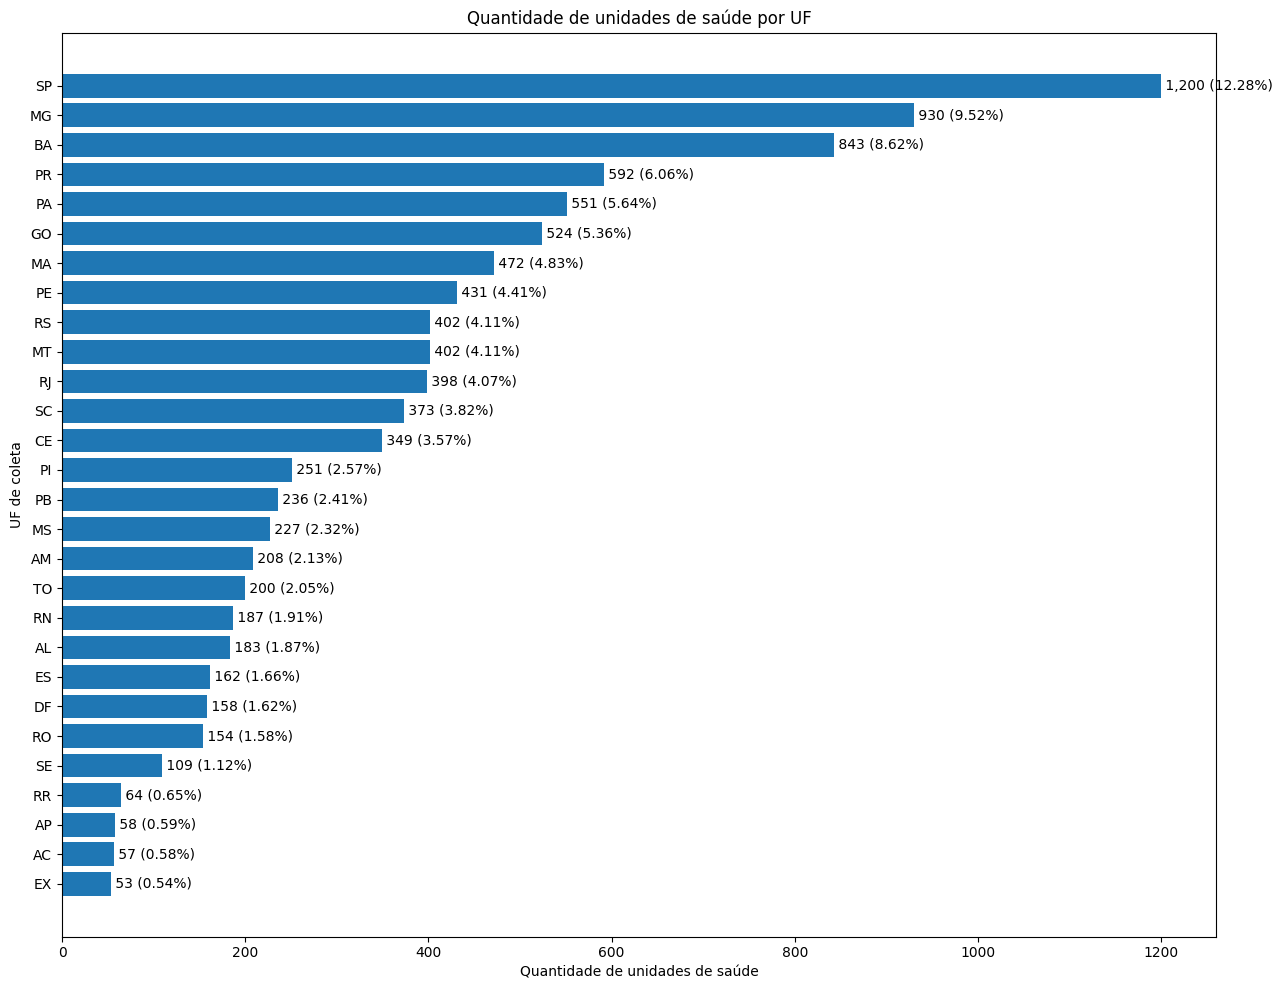

In [70]:
unidades_por_uf = (
    df_sinasc
    .filter(
        col("UF_COLETA").isNotNull() &
        col("CODESTAB").isNotNull()
    )
    .groupBy("UF_COLETA")
    .agg(
        countDistinct("CODESTAB").alias("UNIDADES_SAUDE")
    )
    .orderBy(col("UNIDADES_SAUDE"))
)

df_unidades_uf = unidades_por_uf.toPandas()

df_unidades_uf["PERCENTUAL"] = (
    df_unidades_uf["UNIDADES_SAUDE"]
    / df_unidades_uf["UNIDADES_SAUDE"].sum()
    * 100
)


plt.figure(figsize=(13, 10))

barras = plt.barh(
    df_unidades_uf["UF_COLETA"],
    df_unidades_uf["UNIDADES_SAUDE"]
)

plt.xlabel("Quantidade de unidades de saúde")
plt.ylabel("UF de coleta")
plt.title("Quantidade de unidades de saúde por UF")

for barra, unidades, percentual in zip(
    barras,
    df_unidades_uf["UNIDADES_SAUDE"],
    df_unidades_uf["PERCENTUAL"]
):
    plt.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {unidades:,} ({percentual:.2f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

**Lógica utilizada:** No **Spark**, considerei os registros com `UF_COLETA` e `CODESTAB` preenchidos e agrupei os dados por `UF_COLETA`. Para cada UF, utilizei `countDistinct("CODESTAB")` para contabilizar as unidades de saúde distintas identificadas na base. O resultado agregado foi convertido para **Pandas**, onde calculei o percentual de participação de cada UF em relação ao total de unidades de saúde identificadas. Por fim, utilizei o **Matplotlib** para apresentar a distribuição das unidades de saúde por UF.

**Resultado:** Foram identificadas **9.773 unidades de saúde distintas** na base. São Paulo apresenta a maior quantidade, com **1.200 unidades (12,28%)**, seguido por Minas Gerais, com **930 (9,52%)**, e Bahia, com **843 (8,62%)**. Na sequência aparecem Paraná, com **592 (6,06%)**, e Pará, com **551 (5,64%)**.

Na outra extremidade da distribuição, os menores quantitativos foram observados em **Acre (57 unidades; 0,58%)**, **Amapá (58; 0,59%)**, **Roraima (64; 0,65%)** e **Sergipe (109; 1,12%)**. A categoria `EX`  **Exterior apresentou 53 unidades (0,54%)**, correspondendo aos registros classificados dessa forma na variável `UF_COLETA`.


### Pergunta - 14 Mostre a distribuição dos nascimentos por mês na Bahia.

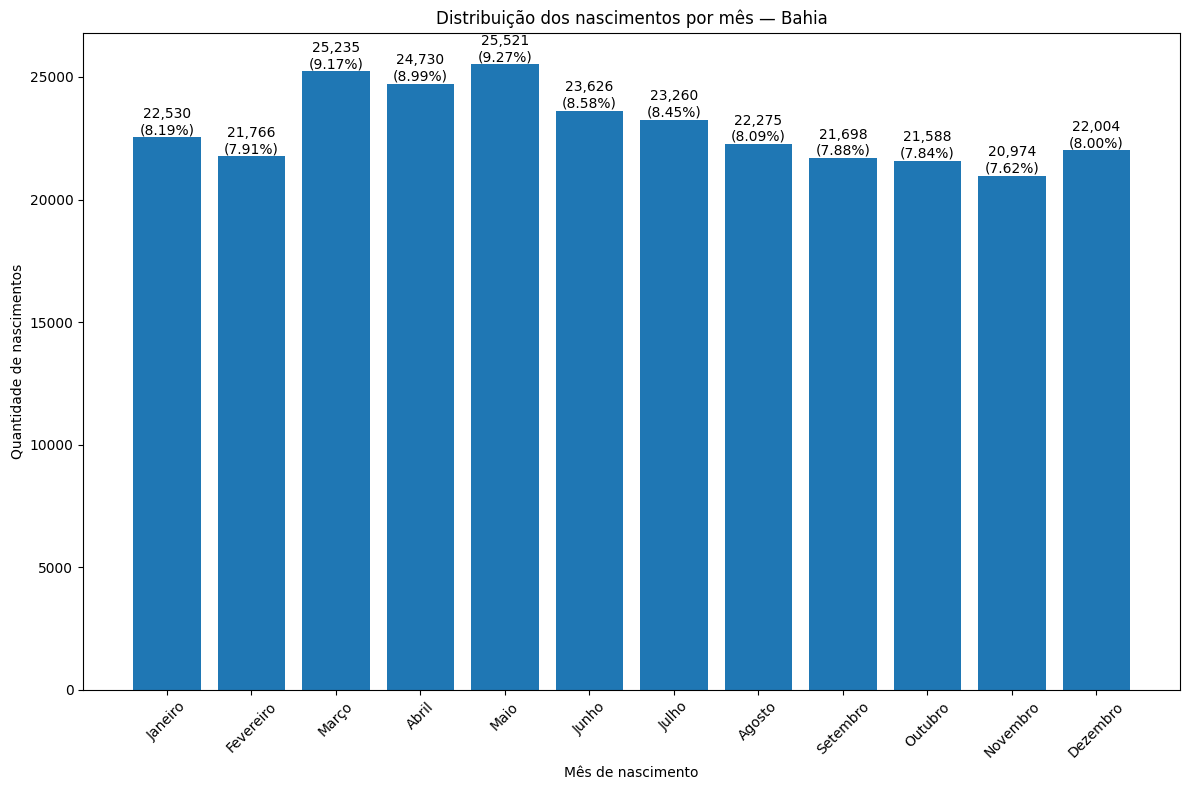

In [71]:
nascimentos_bahia_mes = (
    df_sinasc
    .filter(
        (col("UF_COLETA") == "BA") &
        col("DTNASC").isNotNull()
    )
    .withColumn(
        "MES_NASCIMENTO",
        substring(col("DTNASC"), 3, 2)
    )
    .groupBy("MES_NASCIMENTO")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy("MES_NASCIMENTO")
)

df_bahia_mes = nascimentos_bahia_mes.toPandas()

df_bahia_mes["PERCENTUAL"] = (
    df_bahia_mes["REGISTROS"]
    / df_bahia_mes["REGISTROS"].sum()
    * 100
)

nomes_meses = {
    "01": "Janeiro",
    "02": "Fevereiro",
    "03": "Março",
    "04": "Abril",
    "05": "Maio",
    "06": "Junho",
    "07": "Julho",
    "08": "Agosto",
    "09": "Setembro",
    "10": "Outubro",
    "11": "Novembro",
    "12": "Dezembro"
}

df_bahia_mes["MES"] = df_bahia_mes["MES_NASCIMENTO"].map(nomes_meses)

plt.figure(figsize=(12, 8))

barras = plt.bar(
    df_bahia_mes["MES"],
    df_bahia_mes["REGISTROS"]
)

plt.xlabel("Mês de nascimento")
plt.ylabel("Quantidade de nascimentos")
plt.title("Distribuição dos nascimentos por mês — Bahia")
plt.xticks(rotation=45)

for barra, registros, percentual in zip(
    barras,
    df_bahia_mes["REGISTROS"],
    df_bahia_mes["PERCENTUAL"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{registros:,}\n({percentual:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Lógica utilizada:** No **Spark**, filtrei os registros referentes à Bahia e, a partir da variável `DTNASC`, extraí o mês de nascimento. Em seguida, agrupei os registros por mês e contabilizei a quantidade de nascimentos. O resultado agregado foi convertido para **Pandas**, onde calculei o percentual de cada mês em relação ao total de nascimentos considerados. Por fim, utilizei o **Matplotlib** para apresentar graficamente a distribuição mensal.

**Resultado:** A distribuição dos nascimentos ao longo dos meses apresenta comportamento relativamente equilibrado, sem um mês ou período com diferença muito acentuada em relação aos demais. **Maio** apresenta a maior frequência, com **25.521 registros (9,27%)**, seguido por março, com **25.235 (9,17%)**, e abril, com **24.730 (8,99%)**. Os menores valores aparecem em novembro, com **20.974 registros (7,62%)**, outubro, com **21.588 (7,84%)**, e setembro, com **21.698 (7,88%)**.

De forma geral, embora os meses de **março a maio** apresentem frequências um pouco maiores, a diferença entre os meses é relativamente pequena, não indicando uma concentração expressiva de nascimentos em um período específico.


### Pergunta - 15 Mostre a distribuição do tempo de estudo das mães solteiras e negras que tiveram gêmeos para cada UF.

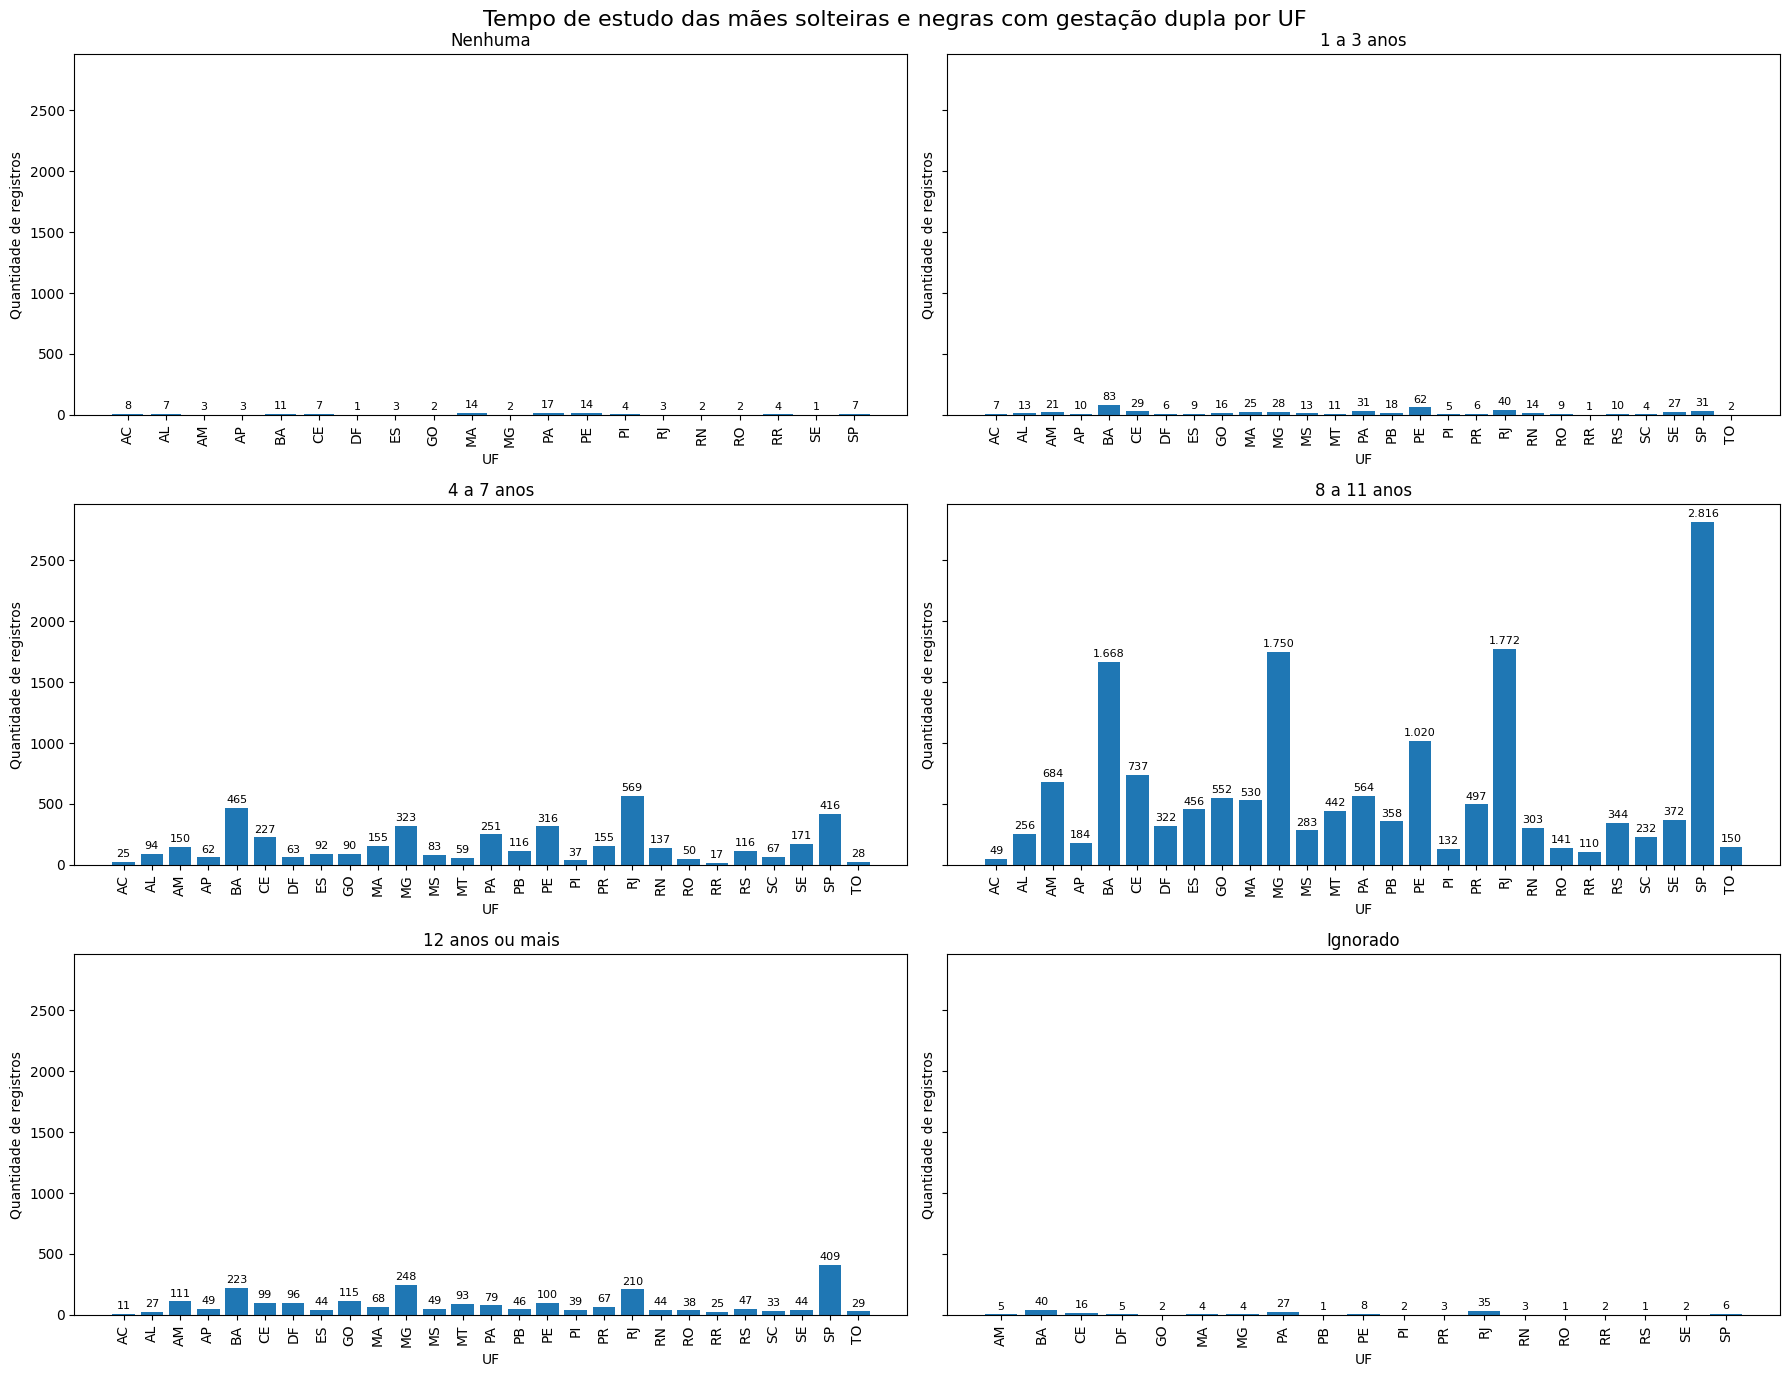

In [72]:
distribuicao_estudo = (
    df_sinasc
    .filter(
        (col("ESTCIVMAE") == "Solteira") &
        col("RACACORMAE").isin("Preta", "Parda") &
        (col("GRAVIDEZ") == "Dupla") &
        col("SIGLA_UF_NASC").isNotNull() &
        col("ESCMAE").isNotNull()
    )
    .groupBy(
        "SIGLA_UF_NASC",
        "ESCMAE"
    )
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy(
        "SIGLA_UF_NASC",
        "ESCMAE"
    )
)

df_estudo = distribuicao_estudo.toPandas()

df_estudo["PERCENTUAL"] = (
    df_estudo["REGISTROS"]
    / df_estudo.groupby("SIGLA_UF_NASC")["REGISTROS"].transform("sum")
    * 100
)


ordem_escolaridade = [
    "Nenhuma",
    "1 a 3 anos",
    "4 a 7 anos",
    "8 a 11 anos",
    "12 anos ou mais",
    "Ignorado"
]

df_grafico = df_estudo[
    df_estudo["ESCMAE"].isin(ordem_escolaridade)
].copy()

fig, axes = plt.subplots(
    3, 2,
    figsize=(18, 14),
    sharey=True
)

axes = axes.flatten()

for i, escolaridade in enumerate(ordem_escolaridade):

    dados = (
        df_grafico[df_grafico["ESCMAE"] == escolaridade]
        .sort_values("SIGLA_UF_NASC")
    )

    barras = axes[i].bar(
        dados["SIGLA_UF_NASC"],
        dados["REGISTROS"]
    )

    axes[i].set_title(escolaridade)
    axes[i].set_xlabel("UF")
    axes[i].set_ylabel("Quantidade de registros")
    axes[i].tick_params(axis="x", rotation=90)

    # Rótulos com a quantidade em cada barra
    axes[i].bar_label(
        barras,
        labels=[f"{valor:,}".replace(",", ".") for valor in dados["REGISTROS"]],
        padding=2,
        fontsize=8
    )



fig.suptitle(
    "Tempo de estudo das mães solteiras e negras com gestação dupla por UF",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Lógica utilizada:** Para responder à questão, primeiro realizei no Spark o filtro das mães com estado civil `Solteira`, raça/cor `Preta` ou `Parda`, gestação `Dupla` e informação preenchida para UF e escolaridade. A distribuição foi então agrupada por `SIGLA_UF_NASC` e `ESCMAE`, obtendo a quantidade de registros em cada combinação.

O resultado agregado pelo Spark foi convertido para Pandas. Nessa etapa, calculei também a participação percentual de cada categoria de escolaridade dentro de cada UF, utilizando como denominador o total de registros daquele estado no recorte (permitindo interpretar a composição do grupo) analisado. Para a visualização, utilizei o Matplotlib com um painel separado para cada categoria de escolaridade, mostrando a quantidade de registros por UF. Essa estrutura foi escolhida para evitar a sobreposição de muitas barras em um único gráfico e facilitar a comparação entre os estados.

**Adendo metodológico:** A variável `RACACORMAE` não possui uma categoria denominada “negra”. Portanto, considerei como negras as mães classificadas como `Preta` ou `Parda`, um critério que já havia sido adotado na questão 7. Essa definição é importante para deixar explícito como o recorte da análise foi construído.

**Resultado:** Para o grupo de mães solteiras, pretas ou pardas, com gestação dupla, a escolaridade mais frequente é **8 a 11 anos de estudo**, seguida por **4 a 7 anos**. Esse padrão se repete na maioria das UFs. Na Bahia, por exemplo, 66,99% dos registros estão na categoria de 8 a 11 anos e 18,67% em 4 a 7 anos. Em São Paulo, as proporções são 76,42% e 11,29%, respectivamente. Também há participação menor das categorias de 12 anos ou mais, 1 a 3 anos e nenhuma escolaridade.

Assim, dentro do recorte analisado, **8 a 11 anos de estudo concentra a maior parte dos registros, seguida por 4 a 7 anos**, embora a distribuição percentual apresente diferenças entre as UFs.


### Pergunta - 16 Qual a porcentagem de mulheres casadas que tiveram parto vaginal e parto cesáreo com menos de 37 semanas de gestação?

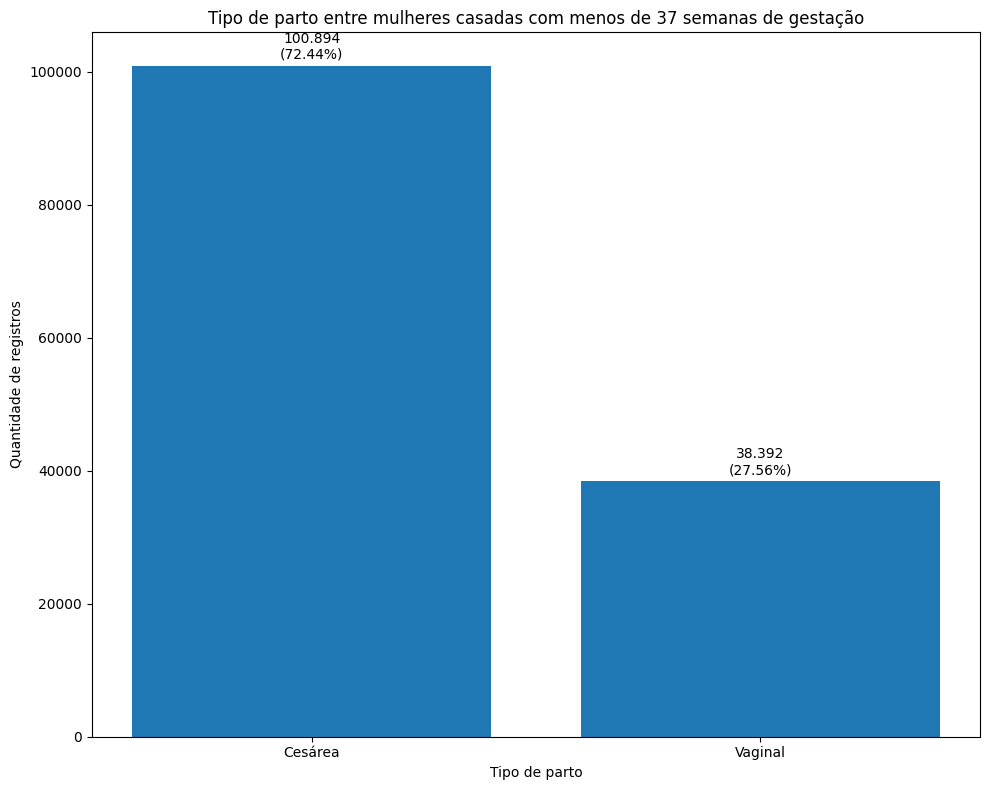

In [73]:
parto_casadas = (
    df_sinasc
    .filter(
        (col("ESTCIVMAE") == "Casada") &
        col("PARTO").isin("Vaginal", "Cesárea") &
        col("GESTACAO").isin(
            "Menos de 22 semanas",
            "22 a 27 semanas",
            "28 a 31 semanas",
            "32 a 36 semanas"
        )
    )
    .groupBy("PARTO")
    .agg(
        count("*").alias("REGISTROS")
    )
    .orderBy("PARTO")
)

df_parto_casadas = parto_casadas.toPandas()

df_parto_casadas["PERCENTUAL"] = (
    df_parto_casadas["REGISTROS"]
    / df_parto_casadas["REGISTROS"].sum()
    * 100
)


# Matplotlib: gráfico da distribuição dos tipos de parto
fig, ax = plt.subplots(figsize=(10, 8))

barras = ax.bar(
    df_parto_casadas["PARTO"],
    df_parto_casadas["REGISTROS"]
)

ax.set_title(
    "Tipo de parto entre mulheres casadas com menos de 37 semanas de gestação"
)
ax.set_xlabel("Tipo de parto")
ax.set_ylabel("Quantidade de registros")

ax.bar_label(
    barras,
    labels=[
        f"{registros:,}".replace(",", ".") + f"\n({percentual:.2f}%)"
        for registros, percentual in zip(
            df_parto_casadas["REGISTROS"],
            df_parto_casadas["PERCENTUAL"]
        )
    ],
    padding=3
)

plt.tight_layout()
plt.show()

**Lógica utilizada:** No Spark, filtrei os registros de mulheres com estado civil `Casada`, considerando os partos classificados como `Vaginal` ou `Cesárea` e as categorias de `GESTACAO` correspondentes a menos de 37 semanas: `Menos de 22 semanas`, `22 a 27 semanas`, `28 a 31 semanas` e `32 a 36 semanas`. Em seguida, agrupei os registros por `PARTO` e obtive a quantidade de ocorrências de cada tipo.

O resultado agregado pelo Spark foi convertido para Pandas, onde calculei a participação percentual de cada tipo de parto sobre o total de registros desse recorte. No Matplotlib, utilizei um gráfico de barras para comparar os dois tipos de parto, apresentando nos rótulos tanto a quantidade absoluta de registros quanto o respectivo percentual.

**Resultado:** Entre as mulheres casadas com parto registrado e gestação inferior a 37 semanas, foram identificados **139.286 registros**. Desse total, **100.894 (72,44%)** correspondem a partos **cesáreos**, enquanto **38.392 (27,56%)** correspondem a partos **vaginais**.



### Pergunta - 17 Qual a relação entre a quantidade de consultas de pré-natal, o tempo de estudo, o estado civil e ou a raça/cor das mães?

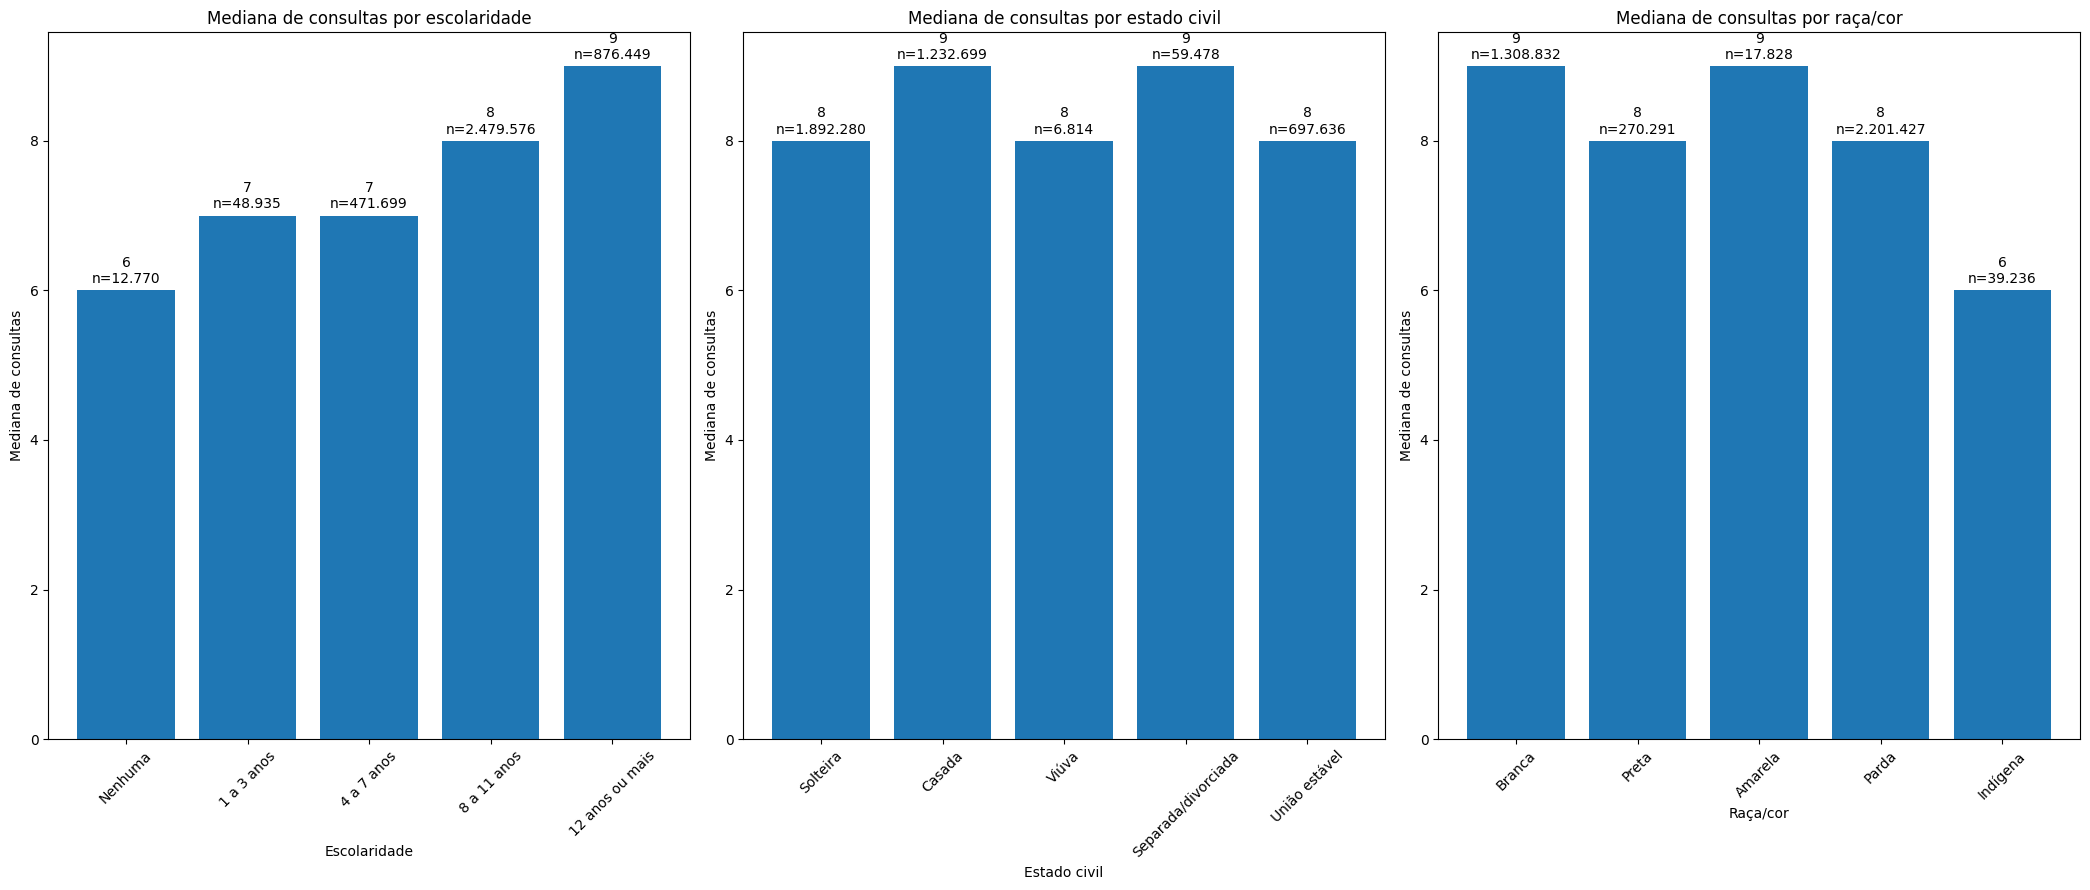

ESCOLARIDADE


,ESCMAE,REGISTROS,MEDIANA_CONSULTAS,PERCENTUAL
4,Nenhuma,12770,6,0.328326
0,1 a 3 anos,48935,7,1.258154
2,4 a 7 anos,471699,7,12.127718
3,8 a 11 anos,2479576,8,63.751672
1,12 anos ou mais,876449,9,22.534130


ESTADO CIVIL


,ESTCIVMAE,REGISTROS,MEDIANA_CONSULTAS,PERCENTUAL
2,Solteira,1892280,8,48.658402
0,Casada,1232699,9,31.697827
4,Viúva,6814,8,0.175216
1,Separada/divorciada,59478,9,1.529427
3,União estável,697636,8,17.939128


RAÇA/COR


,RACACORMAE,REGISTROS,MEDIANA_CONSULTAS,PERCENTUAL
1,Branca,1308832,9,34.105358
4,Preta,270291,8,7.043204
0,Amarela,17828,9,0.464559
3,Parda,2201427,8,57.364472
2,Indígena,39236,6,1.022406


In [74]:
from pyspark.sql.functions import (
    col,
    count,
    percentile_approx
)

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Q17 — Consultas de pré-natal x escolaridade, estado civil
#      e raça/cor da mãe
# ============================================================

# Consideramos apenas registros com número de consultas informado.
df_q17 = (
    df_sinasc
    .filter(col("CONSPRENAT").isNotNull())
)


# ============================================================
# 1. Escolaridade
# ============================================================

q17_escmae = (
    df_q17
    .filter(
        col("ESCMAE").isNotNull() &
        (col("ESCMAE") != "Ignorado")
    )
    .groupBy("ESCMAE")
    .agg(
        count("*").alias("REGISTROS"),
        percentile_approx(
            "CONSPRENAT", 0.5
        ).alias("MEDIANA_CONSULTAS")
    )
    .orderBy("ESCMAE")
)


# ============================================================
# 2. Estado civil
# ============================================================

q17_estciv = (
    df_q17
    .filter(
        col("ESTCIVMAE").isNotNull() &
        (col("ESTCIVMAE") != "Ignorado")
    )
    .groupBy("ESTCIVMAE")
    .agg(
        count("*").alias("REGISTROS"),
        percentile_approx(
            "CONSPRENAT", 0.5
        ).alias("MEDIANA_CONSULTAS")
    )
    .orderBy("ESTCIVMAE")
)


# ============================================================
# 3. Raça/cor
# ============================================================

q17_racacor = (
    df_q17
    .filter(
        col("RACACORMAE").isNotNull() &
        (col("RACACORMAE") != "Ignorado")
    )
    .groupBy("RACACORMAE")
    .agg(
        count("*").alias("REGISTROS"),
        percentile_approx(
            "CONSPRENAT", 0.5
        ).alias("MEDIANA_CONSULTAS")
    )
    .orderBy("RACACORMAE")
)


# ============================================================
# Conversão para Pandas
# ============================================================

df_q17_escmae = q17_escmae.toPandas()
df_q17_estciv = q17_estciv.toPandas()
df_q17_racacor = q17_racacor.toPandas()


# ============================================================
# Percentual de cada grupo dentro do respectivo recorte
# ============================================================

df_q17_escmae["PERCENTUAL"] = (
    df_q17_escmae["REGISTROS"]
    / df_q17_escmae["REGISTROS"].sum()
    * 100
)

df_q17_estciv["PERCENTUAL"] = (
    df_q17_estciv["REGISTROS"]
    / df_q17_estciv["REGISTROS"].sum()
    * 100
)

df_q17_racacor["PERCENTUAL"] = (
    df_q17_racacor["REGISTROS"]
    / df_q17_racacor["REGISTROS"].sum()
    * 100
)


# ============================================================
# Organização das categorias
# ============================================================

ordem_escmae = [
    "Nenhuma",
    "1 a 3 anos",
    "4 a 7 anos",
    "8 a 11 anos",
    "12 anos ou mais"
]

ordem_estciv = [
    "Solteira",
    "Casada",
    "Viúva",
    "Separada/divorciada",
    "União estável"
]

ordem_racacor = [
    "Branca",
    "Preta",
    "Amarela",
    "Parda",
    "Indígena"
]


df_q17_escmae["ESCMAE"] = pd.Categorical(
    df_q17_escmae["ESCMAE"],
    categories=ordem_escmae,
    ordered=True
)

df_q17_estciv["ESTCIVMAE"] = pd.Categorical(
    df_q17_estciv["ESTCIVMAE"],
    categories=ordem_estciv,
    ordered=True
)

df_q17_racacor["RACACORMAE"] = pd.Categorical(
    df_q17_racacor["RACACORMAE"],
    categories=ordem_racacor,
    ordered=True
)


df_q17_escmae = df_q17_escmae.sort_values("ESCMAE")
df_q17_estciv = df_q17_estciv.sort_values("ESTCIVMAE")
df_q17_racacor = df_q17_racacor.sort_values("RACACORMAE")


# ============================================================
# Visualização — 3 painéis
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(21, 9)
)


# ------------------------------------------------------------
# Escolaridade
# ------------------------------------------------------------

barras = axes[0].bar(
    df_q17_escmae["ESCMAE"],
    df_q17_escmae["MEDIANA_CONSULTAS"]
)

axes[0].set_title(
    "Mediana de consultas por escolaridade"
)
axes[0].set_xlabel("Escolaridade")
axes[0].set_ylabel("Mediana de consultas")
axes[0].tick_params(axis="x", rotation=45)

axes[0].bar_label(
    barras,
    labels=[
        f"{mediana}\n"
        f"n={registros:,}".replace(",", ".")
        for mediana, registros in zip(
            df_q17_escmae["MEDIANA_CONSULTAS"],
            df_q17_escmae["REGISTROS"]
        )
    ],
    padding=3
)


# ------------------------------------------------------------
# Estado civil
# ------------------------------------------------------------

barras = axes[1].bar(
    df_q17_estciv["ESTCIVMAE"],
    df_q17_estciv["MEDIANA_CONSULTAS"]
)

axes[1].set_title(
    "Mediana de consultas por estado civil"
)
axes[1].set_xlabel("Estado civil")
axes[1].set_ylabel("Mediana de consultas")
axes[1].tick_params(axis="x", rotation=45)

axes[1].bar_label(
    barras,
    labels=[
        f"{mediana}\n"
        f"n={registros:,}".replace(",", ".")
        for mediana, registros in zip(
            df_q17_estciv["MEDIANA_CONSULTAS"],
            df_q17_estciv["REGISTROS"]
        )
    ],
    padding=3
)


# ------------------------------------------------------------
# Raça/cor
# ------------------------------------------------------------

barras = axes[2].bar(
    df_q17_racacor["RACACORMAE"],
    df_q17_racacor["MEDIANA_CONSULTAS"]
)

axes[2].set_title(
    "Mediana de consultas por raça/cor"
)
axes[2].set_xlabel("Raça/cor")
axes[2].set_ylabel("Mediana de consultas")
axes[2].tick_params(axis="x", rotation=45)

axes[2].bar_label(
    barras,
    labels=[
        f"{mediana}\n"
        f"n={registros:,}".replace(",", ".")
        for mediana, registros in zip(
            df_q17_racacor["MEDIANA_CONSULTAS"],
            df_q17_racacor["REGISTROS"]
        )
    ],
    padding=3
)


plt.tight_layout()
plt.show()


# ============================================================
# Tabelas finais
# ============================================================

print("ESCOLARIDADE")
display(df_q17_escmae)

print("ESTADO CIVIL")
display(df_q17_estciv)

print("RAÇA/COR")
display(df_q17_racacor)

**Lógica utilizada:** No Spark, utilizei `CONSPRENAT` para calcular a mediana do número de consultas de pré-natal por escolaridade, estado civil e raça/cor, considerando apenas registros informados. Os resultados foram convertidos para Pandas para calcular o percentual de cada grupo e organizá-los para análise. O Matplotlib foi utilizado para comparar visualmente as medianas nos três recortes.

A mediana foi utilizada por representar o comportamento central dos grupos e ser menos sensível a valores extremos. Como referência interpretativa, valores próximos de 8 ou 9 consultas são compatíveis com um acompanhamento distribuído ao longo da gestação, embora isso não represente uma regra fixa de uma consulta por mês.

**Resultado:** Considerando essa referência de acompanhamento ao longo da gestação, a maior parte dos grupos apresenta medianas entre 8 e 9 consultas. O grupo indígena apresenta a menor mediana, com 6 consultas, ficando abaixo dos demais grupos analisados. Também chama atenção a diferença observada entre os níveis de escolaridade, com a mediana passando de 6 consultas no grupo sem escolaridade para 9 no grupo com 12 anos ou mais.
